# Avance 1 — Análisis Exploratorio de Datos

**Proyecto**: Sistema Híbrido de Trading: Comparación de Estrategias LLM vs ML Supervisado  
**Maestría en Inteligencia Artificial Aplicada — Tecnológico de Monterrey**  
**Integrante**: Alejandro González Almazán (A00517113)  
**Fecha**: Mayo 2026

---

## Contexto

El dataset contiene **señales de trading** históricas de criptomonedas calculadas a partir de datos OHLCV de Binance. Cada muestra representa una vela horaria etiquetada mediante *hindsight labeling*: para cada punto en el tiempo *T*, se observan las 24 velas siguientes para determinar si el precio alcanzó el take-profit (LONG) o el stop-loss (SHORT) primero.

**Objetivo del EDA**: Comprender la estructura de los datos, identificar patrones relevantes, detectar problemas (valores faltantes, atípicos, alta cardinalidad) y justificar las decisiones de preprocesamiento que se aplicarán al entrenar los modelos ML (XGBoost, Random Forest, LSTM).

**Índice**:
1. [Configuración e Importaciones](#1)
2. [Carga y Estructura de los Datos](#2)
3. [Análisis Univariante](#3)
4. [Análisis Bi/Multivariante](#4)
5. [Preprocesamiento](#5)
6. [Conclusiones](#6)

<a id='1'></a>
## 1. Configuración e Importaciones

In [1]:
import warnings
from pathlib import Path

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

# ── Estilo global ──────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.figsize"] = (14, 5)
LONG_COLOR = "#2ecc71"
SHORT_COLOR = "#e74c3c"
PALETTE = {"LONG": LONG_COLOR, "SHORT": SHORT_COLOR}

# ── Ruta del dataset ──────────────────────────────────────────────────────────
# Ajustar si el notebook se ejecuta desde otro directorio.
CANDIDATES = [
    Path("backtest/data/labeled/dataset.jsonl"),  # desde langgraph/
    Path("../trading_management/langgraph/backtest/data/labeled/dataset.jsonl"),  # desde trading_management/
    Path(r"C:/projects/trading_management/trading_management/langgraph/backtest/data/labeled/dataset.jsonl"),
]
DATASET_PATH = next((p for p in CANDIDATES if p.exists()), None)
assert DATASET_PATH is not None, "Dataset no encontrado. Verifica la ruta CANDIDATES."
print(f"Dataset: {DATASET_PATH.resolve()}")

Dataset: /Users/alexglz/Projects/trading_management/langgraph/backtest/data/labeled/dataset.jsonl


<a id='2'></a>
## 2. Carga y Estructura de los Datos

### 2.1 Carga y aplanado del JSONL

In [2]:
# Mapas de codificación de variables categóricas
HEATMAP_MAP = {"STRONG_BEARISH": 0, "BEARISH": 1, "NEUTRAL": 2, "BULLISH": 3, "STRONG_BULLISH": 4}
STRUCTURE_MAP = {"BEARISH": 0, "RANGE": 1, "BULLISH": 2, "BREAKOUT": 3}


def load_dataset(path: Path) -> pd.DataFrame:
    """Carga el JSONL y lo aplana a un DataFrame con columnas TF-prefijadas."""
    raw = pd.read_json(path, lines=True)

    # Extraer campos del label (que es un dict por fila)
    label_df = pd.json_normalize(raw["label"]).rename(
        columns={
            "bias": "label",
            "confidence": "label_confidence",
            "quality": "label_quality",
            "entry": "label_entry",
            "tp": "label_tp",
            "sl": "label_sl",
        }
    )

    # Aplanar indicators: dict de {tf: {indicator: value}} → columnas tf_indicator
    indicators_flat = pd.json_normalize(raw["indicators"], sep="_")

    # Construir DataFrame final
    df = pd.DataFrame(
        {
            "symbol": raw.get("symbol", "unknown"),
            "timestamp": pd.to_datetime(raw["timestamp"], unit="ms", utc=True),
            "atr_raw": raw.get("atr_raw", np.nan),
        }
    )
    df = pd.concat(
        [
            df,
            label_df[["label", "label_confidence", "label_quality", "label_entry", "label_tp", "label_sl"]],
            indicators_flat,
        ],
        axis=1,
    )
    return df


df_raw = load_dataset(DATASET_PATH)

# Detectar marcos temporales presentes
TF_ORDER = ["15m", "1h", "4h", "1d", "1w"]
TIMEFRAMES = [tf for tf in TF_ORDER if f"{tf}_rsi" in df_raw.columns]
NUMERIC_FEATS = ["price", "rsi", "macd_hist", "adx", "volume_ratio", "atr_ratio", "bb_pos"]
CAT_FEATS = ["heatmap", "structure"]

print(f"Marcos temporales detectados: {TIMEFRAMES}")
print(f"Columnas totales: {df_raw.shape[1]}")
print(f"Muestras totales: {df_raw.shape[0]:,}")
df_raw.head(3)

Marcos temporales detectados: ['1h', '4h', '1d']
Columnas totales: 36
Muestras totales: 56,161


,symbol,timestamp,atr_raw,label,label_confidence,label_quality,label_entry,label_tp,label_sl,1h_price,...,4h_bb_pos,1d_price,1d_heatmap,1d_structure,1d_rsi,1d_macd_hist,1d_adx,1d_volume_ratio,1d_atr_ratio,1d_bb_pos
0,BTCUSDT,2024-11-24 01:00:00+00:00,463.730118,SHORT,10,HIGH,98182.40,96469.06,98646.13,98182.40,...,0.555216,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BTCUSDT,2024-11-24 02:00:00+00:00,457.863681,SHORT,10,HIGH,98390.66,96531.54,98848.52,98390.66,...,0.555216,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,BTCUSDT,2024-11-24 03:00:00+00:00,448.229847,SHORT,10,HIGH,98200.10,96474.37,98648.33,98200.10,...,0.555216,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2.2 Forma y tipos de datos

In [3]:
print("=== Forma del dataset ===")
print(f"  Filas   : {df_raw.shape[0]:,}")
print(f"  Columnas: {df_raw.shape[1]}")

print("\n=== Tipos de datos ===")
dtype_summary = df_raw.dtypes.value_counts().rename_axis("dtype").reset_index(name="count")
print(dtype_summary.to_string(index=False))

print("\n=== Rango temporal ===")
print(f"  Inicio : {df_raw['timestamp'].min()}")
print(f"  Fin    : {df_raw['timestamp'].max()}")
print(f"  Duración: {(df_raw['timestamp'].max() - df_raw['timestamp'].min()).days} días")

=== Forma del dataset ===
  Filas   : 56,161
  Columnas: 36

=== Tipos de datos ===
              dtype  count
            float64     25
                str      9
datetime64[ms, UTC]      1
              int64      1

=== Rango temporal ===
  Inicio : 2024-11-23 08:00:00+00:00
  Fin    : 2026-05-08 00:00:00+00:00
  Duración: 530 días


### 2.3 Estadísticas descriptivas — Variables numéricas

In [4]:
# Columnas numéricas de indicadores (excluye precio que varía por par)
numeric_cols = [f"{tf}_{feat}" for tf in TIMEFRAMES for feat in NUMERIC_FEATS if f"{tf}_{feat}" in df_raw.columns]
numeric_cols += ["atr_raw", "label_confidence"]

desc = df_raw[numeric_cols].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T
desc["skew"] = df_raw[numeric_cols].skew()
desc["kurtosis"] = df_raw[numeric_cols].kurtosis()

with pd.option_context("display.float_format", "{:.4f}".format, "display.max_rows", 60):
    print(desc[["count", "mean", "std", "min", "5%", "25%", "50%", "75%", "95%", "max", "skew", "kurtosis"]])

                      count      mean        std        min       5%     25%  \
1h_price         56161.0000 8588.4909 27056.6630     0.0876   0.1971  1.9230   
1h_rsi           56161.0000   49.7842    12.9951     9.1507  28.9976 40.3958   
1h_macd_hist     56161.0000    0.2474    49.1643  -929.5629  -9.1682 -0.0179   
1h_adx           56161.0000   28.3382    10.6217    15.0015  16.1876 20.1030   
1h_volume_ratio  56161.0000    1.1962     0.8358     0.5000   0.5377  0.6889   
1h_atr_ratio     56161.0000    1.0302     0.1572     0.6375   0.8232  0.9217   
1h_bb_pos        56161.0000    0.4970     0.3603    -0.5589  -0.0618  0.2000   
4h_price         56161.0000 8586.8222 27050.9103     0.0887   0.1975  1.9172   
4h_rsi           56161.0000   49.3801    12.5921     9.9745  29.0829 40.5871   
4h_macd_hist     56161.0000   -0.2908    86.0957 -1075.6151 -19.8727 -0.0389   
4h_adx           56161.0000   27.0565    11.3557     7.6368  12.7763 18.4131   
4h_volume_ratio  56161.0000    1.1747   

### 2.4 Distribución de la variable objetivo

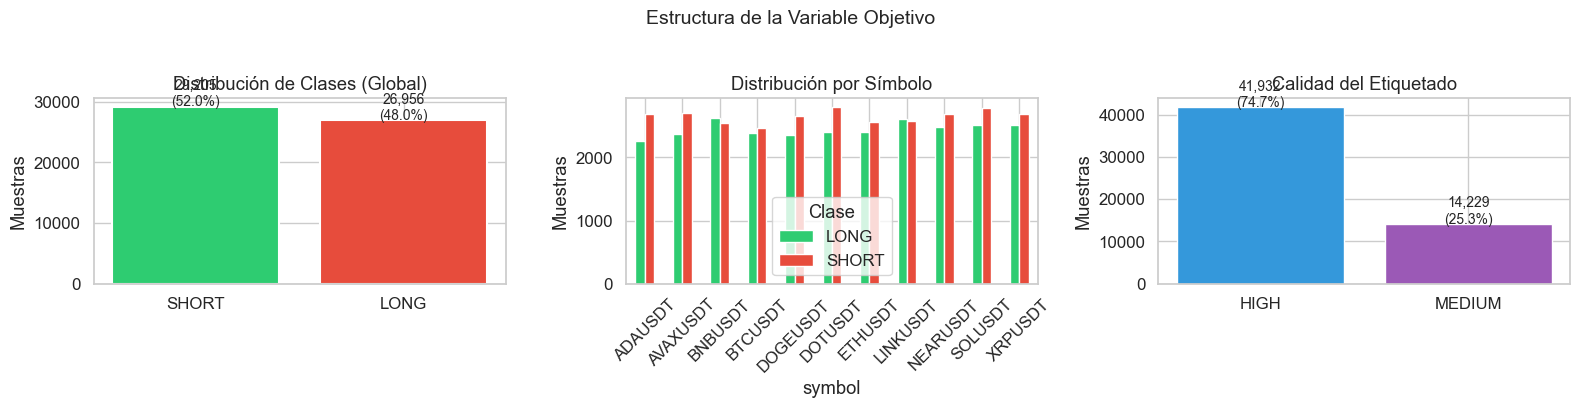


Balance de clases:
  SHORT: 29,205 (52.00%)
  LONG: 26,956 (48.00%)


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# -- Distribución global de clases
vc = df_raw["label"].value_counts()
axes[0].bar(vc.index, vc.values, color=[LONG_COLOR, SHORT_COLOR], edgecolor="white", linewidth=1.5)
for i, (lbl, cnt) in enumerate(vc.items()):
    axes[0].text(i, cnt + 50, f"{cnt:,}\n({cnt / len(df_raw) * 100:.1f}%)", ha="center", fontsize=10)
axes[0].set_title("Distribución de Clases (Global)")
axes[0].set_ylabel("Muestras")

# -- Por símbolo
sym_lbl = df_raw.groupby(["symbol", "label"]).size().unstack(fill_value=0)
sym_lbl.plot(kind="bar", ax=axes[1], color=[LONG_COLOR, SHORT_COLOR], edgecolor="white")
axes[1].set_title("Distribución por Símbolo")
axes[1].set_ylabel("Muestras")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(title="Clase")

# -- Distribución de calidad del label
qc = df_raw["label_quality"].value_counts()
axes[2].bar(qc.index, qc.values, color=["#3498db", "#9b59b6"], edgecolor="white")
for i, (q, cnt) in enumerate(qc.items()):
    axes[2].text(i, cnt + 50, f"{cnt:,}\n({cnt / len(df_raw) * 100:.1f}%)", ha="center", fontsize=10)
axes[2].set_title("Calidad del Etiquetado")
axes[2].set_ylabel("Muestras")

plt.suptitle("Estructura de la Variable Objetivo", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nBalance de clases:")
for lbl, cnt in vc.items():
    print(f"  {lbl}: {cnt:,} ({cnt / len(df_raw) * 100:.2f}%)")

### 2.5 Frecuencia de variables categóricas

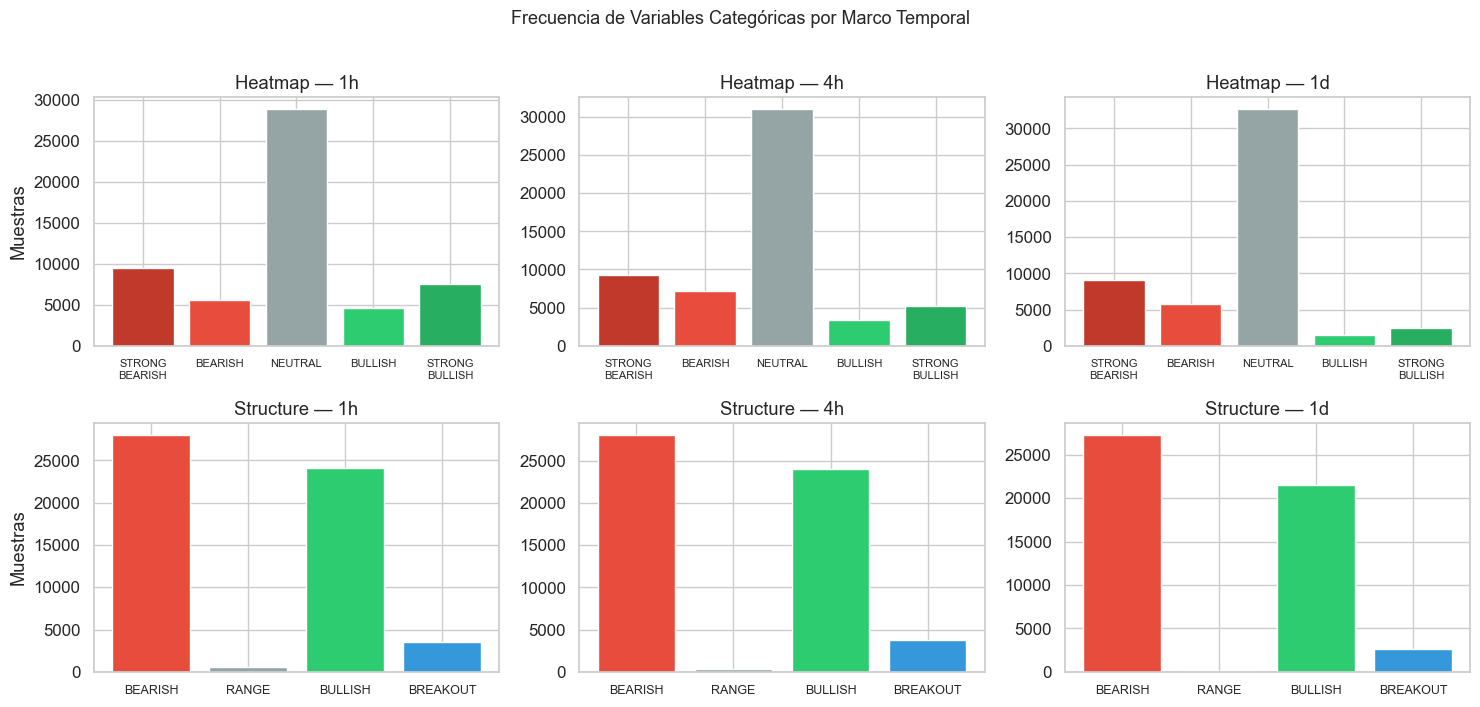


Cardinalidad:
  1h_heatmap: 5 clases únicas → {'NEUTRAL': 28977, 'STRONG_BEARISH': 9488, 'STRONG_BULLISH': 7565, 'BEARISH': 5559, 'BULLISH': 4572}
  4h_heatmap: 5 clases únicas → {'NEUTRAL': 31081, 'STRONG_BEARISH': 9277, 'BEARISH': 7137, 'STRONG_BULLISH': 5258, 'BULLISH': 3408}
  1d_heatmap: 5 clases únicas → {'NEUTRAL': 32735, 'STRONG_BEARISH': 9034, 'BEARISH': 5836, 'STRONG_BULLISH': 2474, 'BULLISH': 1496}
  1h_structure: 4 clases únicas → {'BEARISH': 28040, 'BULLISH': 24101, 'BREAKOUT': 3490, 'RANGE': 530}
  4h_structure: 4 clases únicas → {'BEARISH': 28082, 'BULLISH': 24032, 'BREAKOUT': 3769, 'RANGE': 278}
  1d_structure: 4 clases únicas → {'BEARISH': 27326, 'BULLISH': 21479, 'BREAKOUT': 2671, 'RANGE': 99}


In [6]:
fig, axes = plt.subplots(2, len(TIMEFRAMES), figsize=(15, 7))
heatmap_order = ["STRONG_BEARISH", "BEARISH", "NEUTRAL", "BULLISH", "STRONG_BULLISH"]
structure_order = ["BEARISH", "RANGE", "BULLISH", "BREAKOUT"]
heatmap_colors = ["#c0392b", "#e74c3c", "#95a5a6", "#2ecc71", "#27ae60"]
structure_colors = ["#e74c3c", "#95a5a6", "#2ecc71", "#3498db"]

for col_i, tf in enumerate(TIMEFRAMES):
    # Heatmap
    hm_col = f"{tf}_heatmap"
    if hm_col in df_raw.columns:
        vc = df_raw[hm_col].value_counts().reindex(heatmap_order, fill_value=0)
        axes[0, col_i].bar(range(len(vc)), vc.values, color=heatmap_colors, edgecolor="white")
        axes[0, col_i].set_xticks(range(len(vc)))
        axes[0, col_i].set_xticklabels([x.replace("_", "\n") for x in vc.index], fontsize=8)
        axes[0, col_i].set_title(f"Heatmap — {tf}")
        axes[0, col_i].set_ylabel("Muestras" if col_i == 0 else "")

    # Structure
    st_col = f"{tf}_structure"
    if st_col in df_raw.columns:
        vc = df_raw[st_col].value_counts().reindex(structure_order, fill_value=0)
        axes[1, col_i].bar(range(len(vc)), vc.values, color=structure_colors, edgecolor="white")
        axes[1, col_i].set_xticks(range(len(vc)))
        axes[1, col_i].set_xticklabels(vc.index, fontsize=9)
        axes[1, col_i].set_title(f"Structure — {tf}")
        axes[1, col_i].set_ylabel("Muestras" if col_i == 0 else "")

plt.suptitle("Frecuencia de Variables Categóricas por Marco Temporal", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("\nCardinalidad:")
for feat in CAT_FEATS:
    for tf in TIMEFRAMES:
        col = f"{tf}_{feat}"
        if col in df_raw.columns:
            print(f"  {col}: {df_raw[col].nunique()} clases únicas → {df_raw[col].value_counts().to_dict()}")

### 2.6 Valores faltantes

=== Resumen de Valores Faltantes ===
Total NaN: 41,274  de  2,021,796 celdas
Porcentaje global: 2.04%

NaN por marco temporal:
  1h  :     0 filas NaN  (0.0%)
  4h  :     0 filas NaN  (0.0%)
  1d  : 4,586 filas NaN  (8.2%)

Origen: el TF lento (1d) requiere ~200 velas de lookback para calcular
EMA-200, Bollinger, etc. Al inicio del dataset (Nov 2024) no hay historial
suficiente → TA-Lib devuelve NaN en esas posiciones.
Los TFs rápidos (1h, 4h) no presentan NaN.


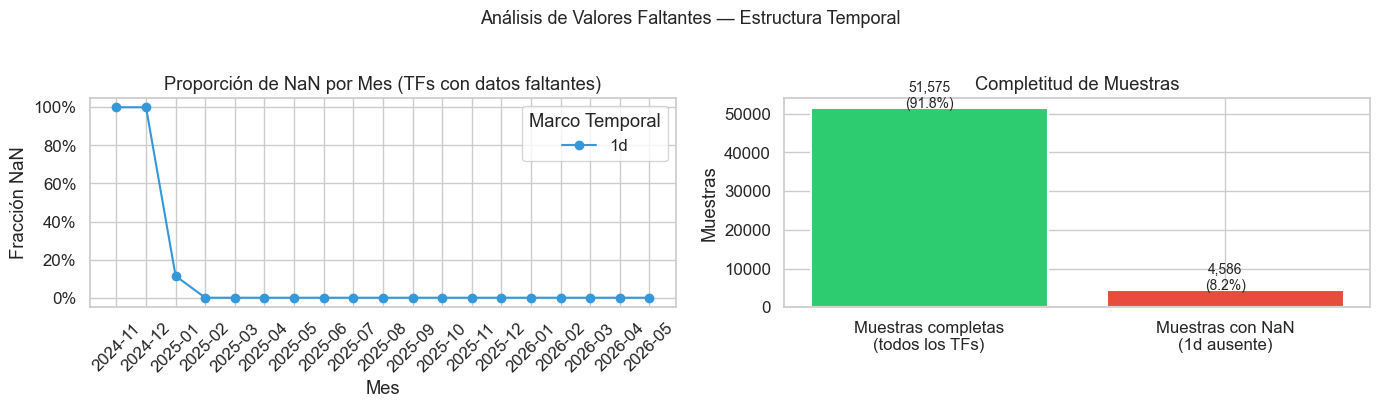


Estrategia: El pipeline de extract_features() rellena con 0.0 los TFs ausentes.
Los modelos ML reciben vectores de dimensión fija independientemente del TF disponible.


In [7]:
missing = df_raw.isnull().sum()
missing_pct = missing / len(df_raw) * 100
missing_df = pd.DataFrame({"nulos": missing, "pct": missing_pct}).query("nulos > 0")

total_nan = df_raw.isnull().sum().sum()
print("=== Resumen de Valores Faltantes ===")
print(f"Total NaN: {total_nan:,}  de  {df_raw.shape[0] * df_raw.shape[1]:,} celdas")
print(f"Porcentaje global: {total_nan / (df_raw.shape[0] * df_raw.shape[1]) * 100:.2f}%")
print()

print("NaN por marco temporal:")
for tf in TIMEFRAMES:
    rsi_col = f"{tf}_rsi"
    nan_rows = df_raw[rsi_col].isnull().sum() if rsi_col in df_raw.columns else 0
    print(f"  {tf:<4}: {nan_rows:>5,} filas NaN  ({nan_rows / len(df_raw) * 100:.1f}%)")

print()
print("Origen: el TF lento (1d) requiere ~200 velas de lookback para calcular")
print("EMA-200, Bollinger, etc. Al inicio del dataset (Nov 2024) no hay historial")
print("suficiente → TA-Lib devuelve NaN en esas posiciones.")
print("Los TFs rápidos (1h, 4h) no presentan NaN.")

# Visualización: evolución de NaN por mes para los TFs afectados
df_raw["month"] = df_raw["timestamp"].dt.to_period("M")
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Mapa de calor: porcentaje de NaN por mes y TF
nan_matrix = {}
for tf in ["1d", "1w"]:
    rsi_col = f"{tf}_rsi"
    if rsi_col in df_raw.columns:
        nan_matrix[tf] = df_raw.groupby("month")[rsi_col].apply(lambda x: x.isnull().mean())

if nan_matrix:
    nan_df = pd.DataFrame(nan_matrix)
    nan_df.index = nan_df.index.astype(str)
    for tf, color in zip(nan_df.columns, ["#3498db", "#e67e22"]):
        axes[0].plot(nan_df.index, nan_df[tf], marker="o", label=tf, color=color)
    axes[0].set_title("Proporción de NaN por Mes (TFs con datos faltantes)")
    axes[0].set_ylabel("Fracción NaN")
    axes[0].set_xlabel("Mes")
    axes[0].tick_params(axis="x", rotation=45)
    axes[0].legend(title="Marco Temporal")
    axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

# Distribución de muestras con NaN vs completas
complete = df_raw.dropna(subset=[f"{tf}_rsi" for tf in TIMEFRAMES if f"{tf}_rsi" in df_raw.columns]).shape[0]
incomplete = len(df_raw) - complete
axes[1].bar(
    ["Muestras completas\n(todos los TFs)", "Muestras con NaN\n(1d ausente)"],
    [complete, incomplete],
    color=["#2ecc71", "#e74c3c"],
    edgecolor="white",
    linewidth=1.5,
)
axes[1].text(0, complete + 30, f"{complete:,}\n({complete / len(df_raw) * 100:.1f}%)", ha="center", fontsize=10)
axes[1].text(1, incomplete + 30, f"{incomplete:,}\n({incomplete / len(df_raw) * 100:.1f}%)", ha="center", fontsize=10)
axes[1].set_title("Completitud de Muestras")
axes[1].set_ylabel("Muestras")

plt.suptitle("Análisis de Valores Faltantes — Estructura Temporal", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\nEstrategia: El pipeline de extract_features() rellena con 0.0 los TFs ausentes.")
print("Los modelos ML reciben vectores de dimensión fija independientemente del TF disponible.")

---
<a id='3'></a>
## 3. Análisis Univariante

### 3.1 Histogramas — Variables numéricas por marco temporal

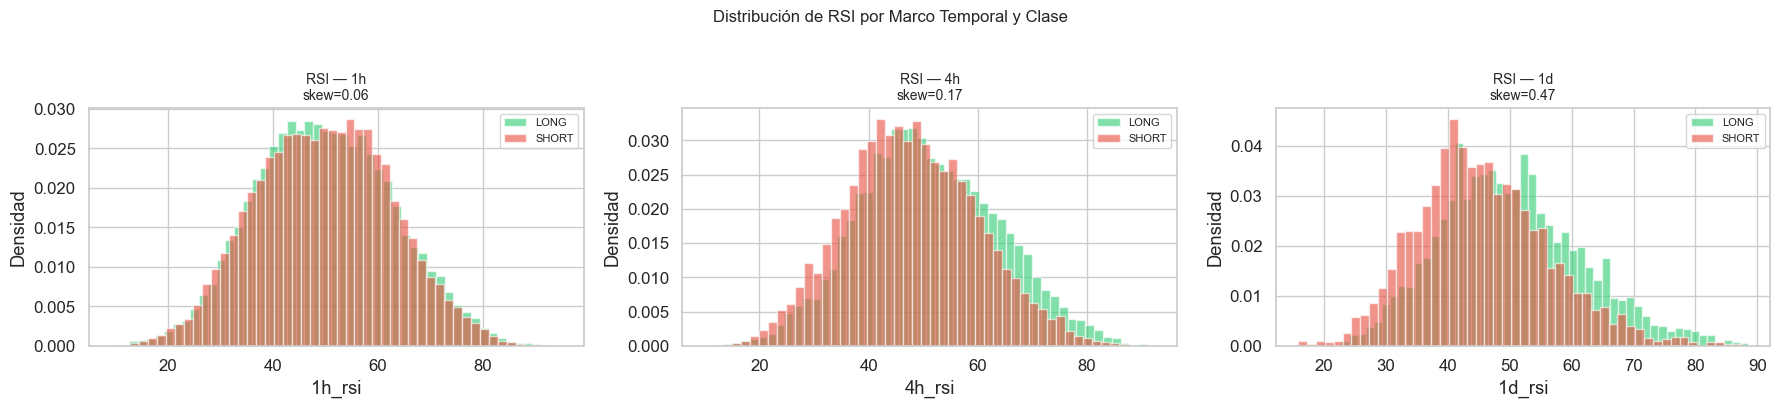

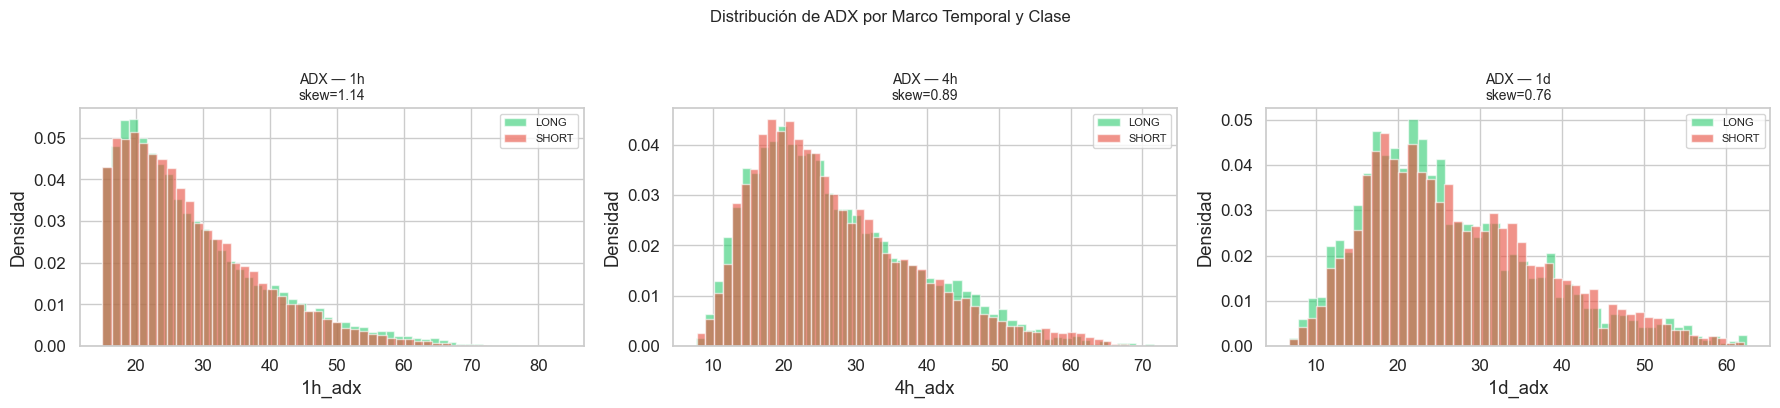

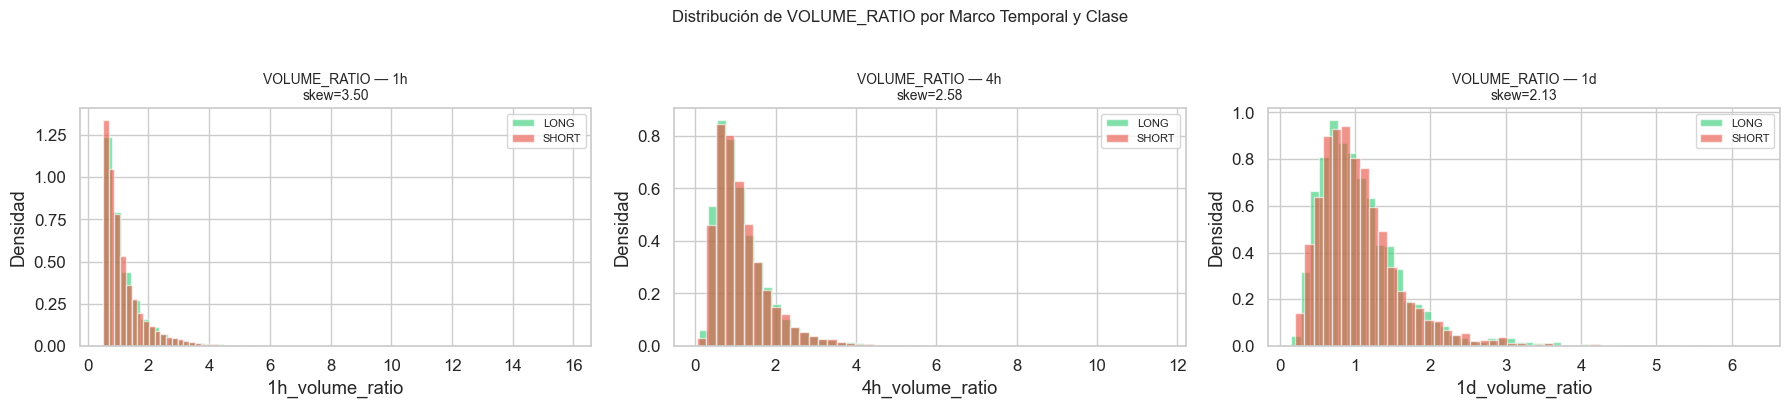

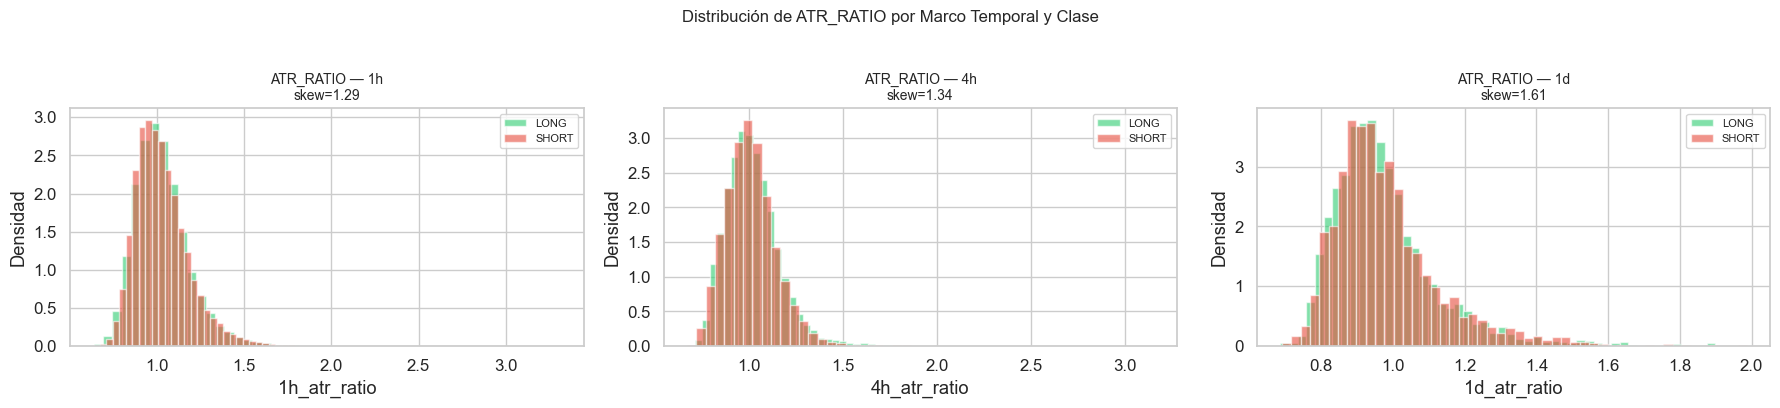

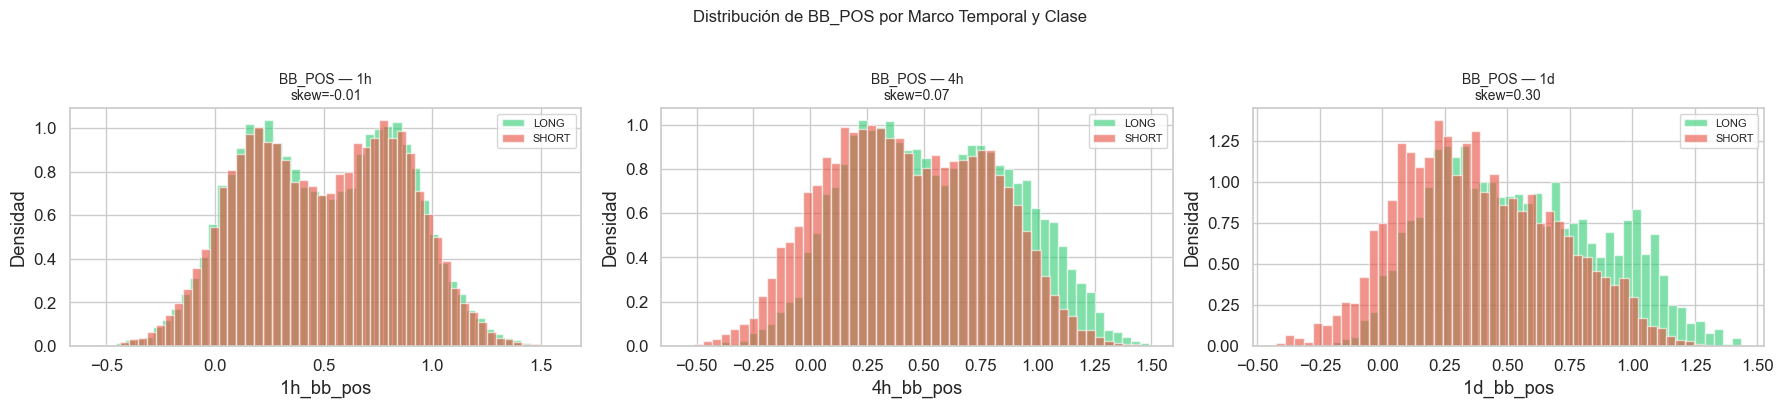

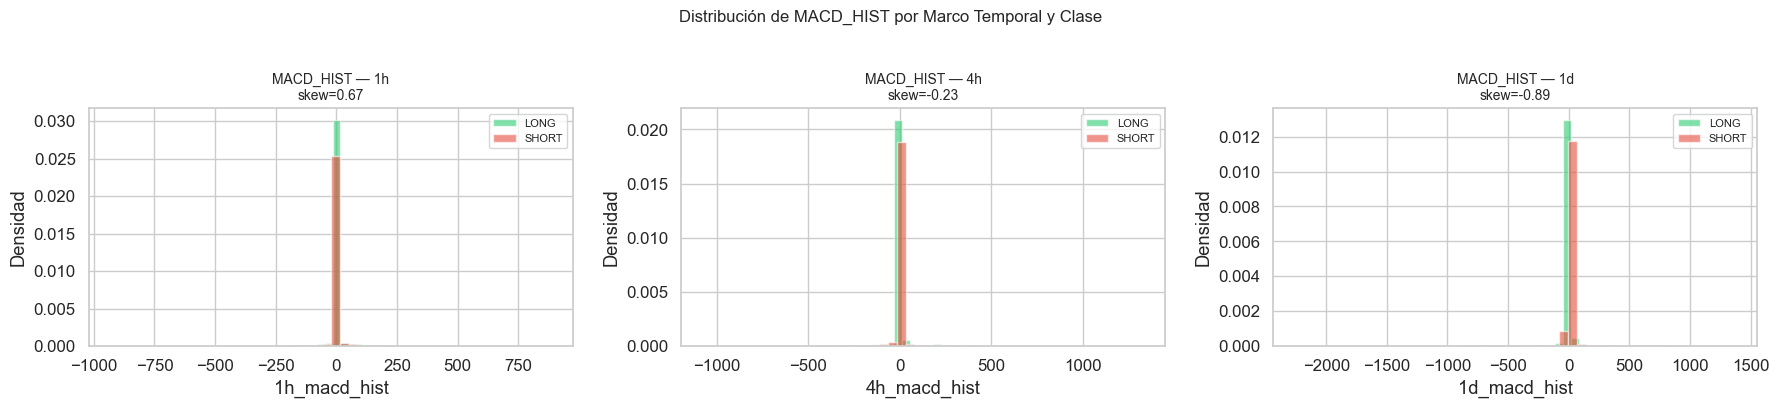

In [8]:
feats_to_plot = ["rsi", "adx", "volume_ratio", "atr_ratio", "bb_pos", "macd_hist"]

for feat in feats_to_plot:
    cols_feat = [f"{tf}_{feat}" for tf in TIMEFRAMES if f"{tf}_{feat}" in df_raw.columns]
    n = len(cols_feat)
    if n == 0:
        continue

    fig, axes = plt.subplots(1, n, figsize=(6 * n, 4))
    if n == 1:
        axes = [axes]

    for ax, col in zip(axes, cols_feat):
        tf = col.split("_")[0]
        data = df_raw[col].dropna()

        ax.hist(data[df_raw["label"] == "LONG"], bins=50, alpha=0.6, color=LONG_COLOR, label="LONG", density=True)
        ax.hist(data[df_raw["label"] == "SHORT"], bins=50, alpha=0.6, color=SHORT_COLOR, label="SHORT", density=True)

        skew_val = data.skew()
        ax.set_title(f"{feat.upper()} — {tf}\nskew={skew_val:.2f}", fontsize=10)
        ax.set_xlabel(col)
        ax.set_ylabel("Densidad")
        ax.legend(fontsize=8)

    plt.suptitle(f"Distribución de {feat.upper()} por Marco Temporal y Clase", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

### 3.2 Boxplots — Detección visual de outliers

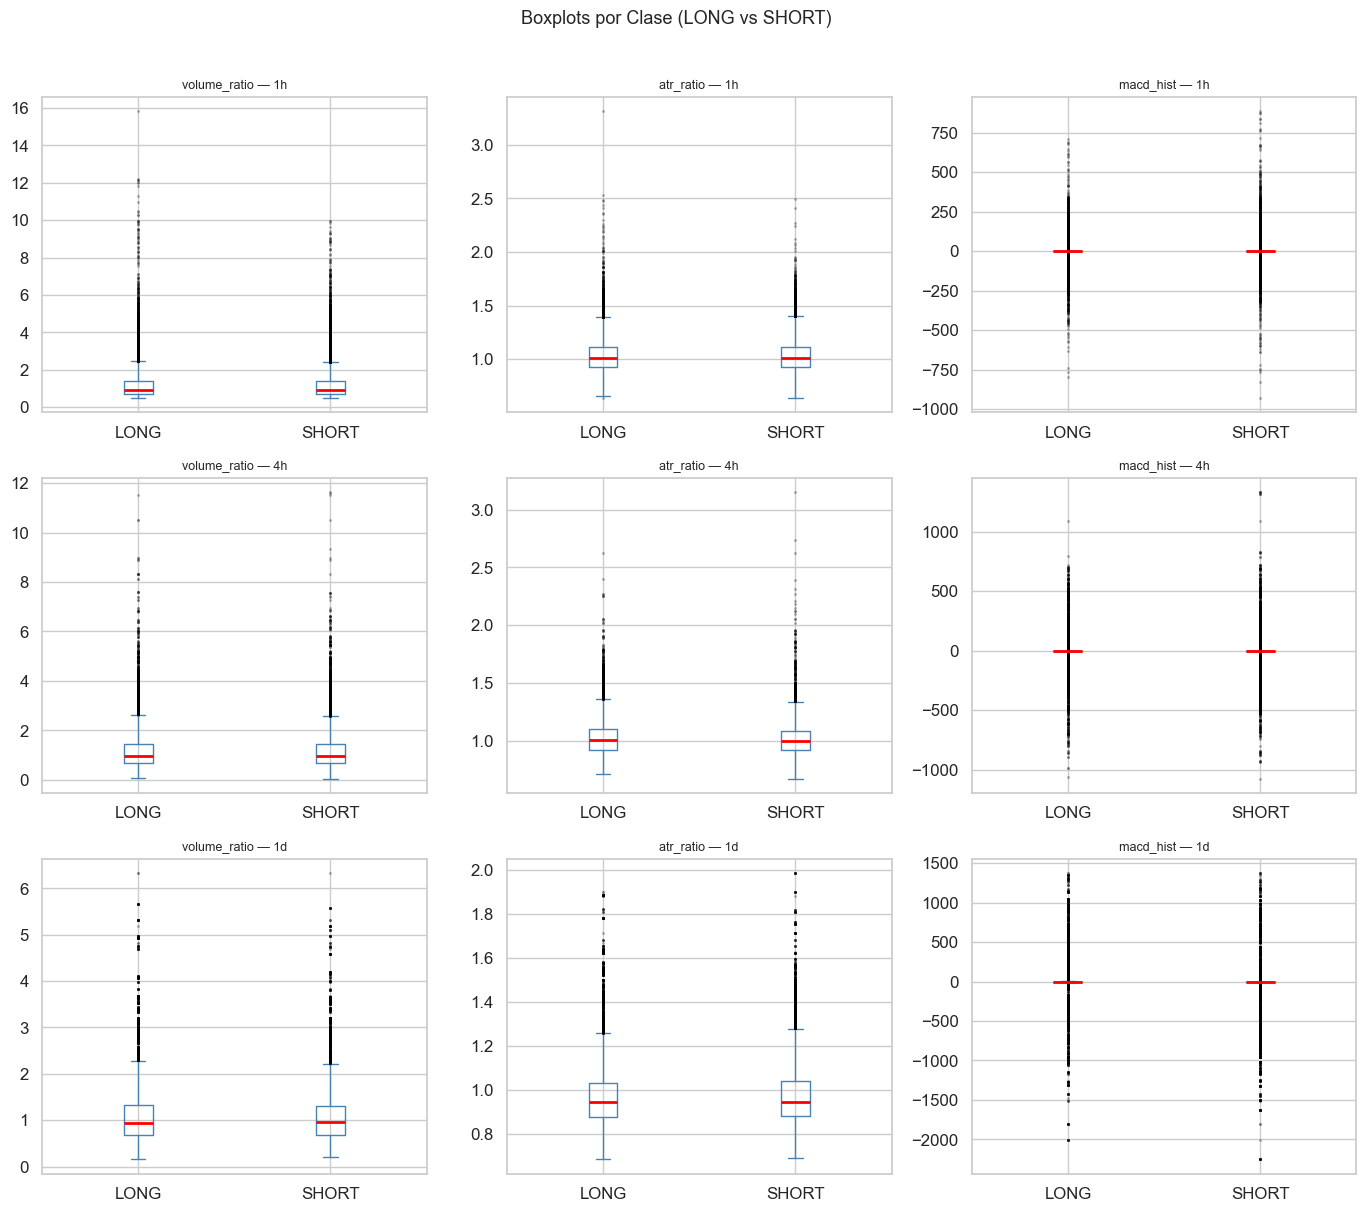

In [9]:
outlier_feats = ["volume_ratio", "atr_ratio", "macd_hist"]

fig, axes = plt.subplots(len(TIMEFRAMES), len(outlier_feats), figsize=(14, 4 * len(TIMEFRAMES)))
if len(TIMEFRAMES) == 1:
    axes = [axes]

for row_i, tf in enumerate(TIMEFRAMES):
    for col_i, feat in enumerate(outlier_feats):
        col = f"{tf}_{feat}"
        ax = axes[row_i][col_i]
        if col not in df_raw.columns:
            ax.axis("off")
            continue

        df_raw.boxplot(
            column=col,
            by="label",
            ax=ax,
            boxprops=dict(color="steelblue"),
            medianprops=dict(color="red", linewidth=2),
            whiskerprops=dict(color="steelblue"),
            capprops=dict(color="steelblue"),
            flierprops=dict(marker=".", markersize=2, alpha=0.3),
        )
        ax.set_title(f"{feat} — {tf}", fontsize=9)
        ax.set_xlabel("")

plt.suptitle("Boxplots por Clase (LONG vs SHORT)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 3.3 Distribución temporal — Evolución en el tiempo

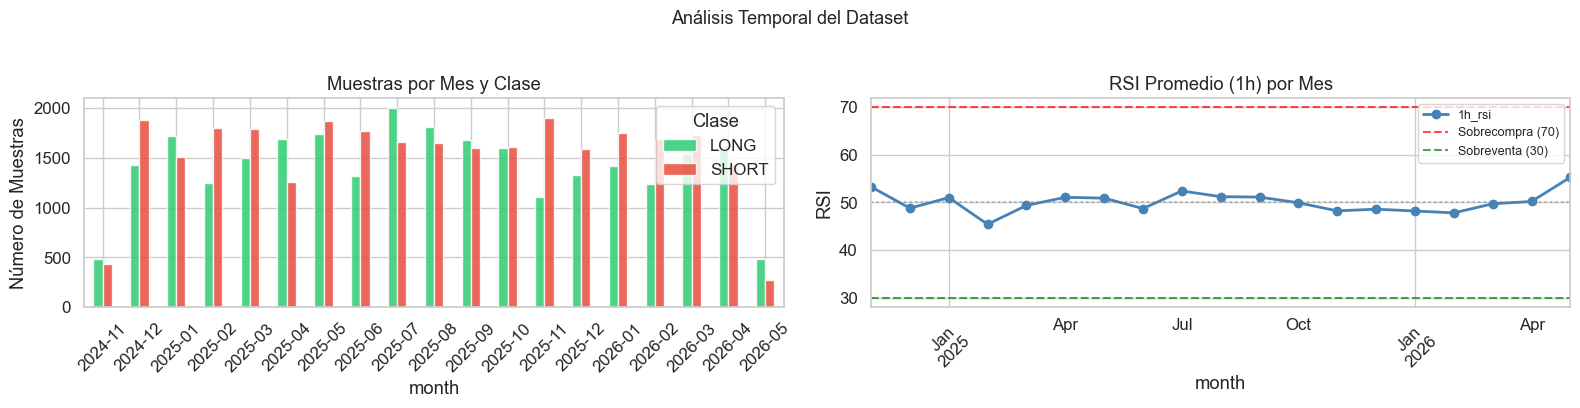

In [10]:
df_raw["month"] = df_raw["timestamp"].dt.to_period("M")

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Muestras por mes y clase
monthly = df_raw.groupby(["month", "label"]).size().unstack(fill_value=0)
monthly.plot(kind="bar", ax=axes[0], color=[LONG_COLOR, SHORT_COLOR], edgecolor="white", alpha=0.85)
axes[0].set_title("Muestras por Mes y Clase")
axes[0].set_ylabel("Número de Muestras")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(title="Clase")

# RSI promedio por mes (1h)
if "1h_rsi" in df_raw.columns:
    monthly_rsi = df_raw.groupby("month")["1h_rsi"].mean()
    monthly_rsi.plot(ax=axes[1], color="steelblue", marker="o", linewidth=2)
    axes[1].axhline(70, color="red", linestyle="--", alpha=0.7, label="Sobrecompra (70)")
    axes[1].axhline(30, color="green", linestyle="--", alpha=0.7, label="Sobreventa (30)")
    axes[1].axhline(50, color="gray", linestyle=":", alpha=0.5)
    axes[1].set_title("RSI Promedio (1h) por Mes")
    axes[1].set_ylabel("RSI")
    axes[1].tick_params(axis="x", rotation=45)
    axes[1].legend(fontsize=9)

plt.suptitle("Análisis Temporal del Dataset", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 3.4 Confianza del etiquetado

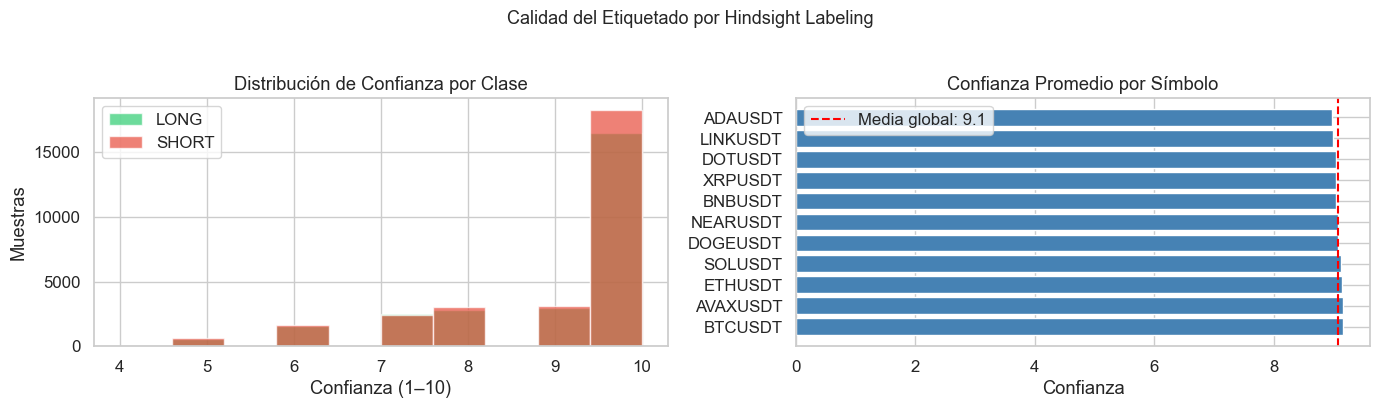

Confianza media global: 9.07
Confianza mediana: 10.0


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma de confianza por clase
for lbl, color in PALETTE.items():
    subset = df_raw[df_raw["label"] == lbl]["label_confidence"]
    axes[0].hist(subset, bins=10, alpha=0.7, color=color, label=lbl, edgecolor="white")
axes[0].set_title("Distribución de Confianza por Clase")
axes[0].set_xlabel("Confianza (1–10)")
axes[0].set_ylabel("Muestras")
axes[0].legend()

# Confianza promedio por símbolo
sym_conf = df_raw.groupby("symbol")["label_confidence"].mean().sort_values(ascending=False)
axes[1].barh(sym_conf.index, sym_conf.values, color="steelblue", edgecolor="white")
axes[1].axvline(
    df_raw["label_confidence"].mean(),
    color="red",
    linestyle="--",
    label=f"Media global: {df_raw['label_confidence'].mean():.1f}",
)
axes[1].set_title("Confianza Promedio por Símbolo")
axes[1].set_xlabel("Confianza")
axes[1].legend()

plt.suptitle("Calidad del Etiquetado por Hindsight Labeling", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Confianza media global: {df_raw['label_confidence'].mean():.2f}")
print(f"Confianza mediana: {df_raw['label_confidence'].median():.1f}")

---
<a id='4'></a>
## 4. Análisis Bi/Multivariante

### 4.1 Codificación de variables categóricas para análisis numérico

In [12]:
df = df_raw.copy()

# Codificar categóricas
for tf in TIMEFRAMES:
    hm_col = f"{tf}_heatmap"
    st_col = f"{tf}_structure"
    if hm_col in df.columns:
        df[f"{tf}_heatmap_enc"] = df[hm_col].map(HEATMAP_MAP)
    if st_col in df.columns:
        df[f"{tf}_structure_enc"] = df[st_col].map(STRUCTURE_MAP)

# Variable objetivo binaria
df["label_bin"] = (df["label"] == "LONG").astype(int)

# Columnas numéricas completas para correlación
corr_cols = (
    [f"{tf}_{feat}" for tf in TIMEFRAMES for feat in NUMERIC_FEATS if f"{tf}_{feat}" in df.columns]
    + [f"{tf}_heatmap_enc" for tf in TIMEFRAMES if f"{tf}_heatmap_enc" in df.columns]
    + [f"{tf}_structure_enc" for tf in TIMEFRAMES if f"{tf}_structure_enc" in df.columns]
)

print(f"Variables numéricas para análisis: {len(corr_cols)}")
print(corr_cols)

Variables numéricas para análisis: 27
['1h_price', '1h_rsi', '1h_macd_hist', '1h_adx', '1h_volume_ratio', '1h_atr_ratio', '1h_bb_pos', '4h_price', '4h_rsi', '4h_macd_hist', '4h_adx', '4h_volume_ratio', '4h_atr_ratio', '4h_bb_pos', '1d_price', '1d_rsi', '1d_macd_hist', '1d_adx', '1d_volume_ratio', '1d_atr_ratio', '1d_bb_pos', '1h_heatmap_enc', '4h_heatmap_enc', '1d_heatmap_enc', '1h_structure_enc', '4h_structure_enc', '1d_structure_enc']


### 4.2 Matriz de correlación (Pearson)

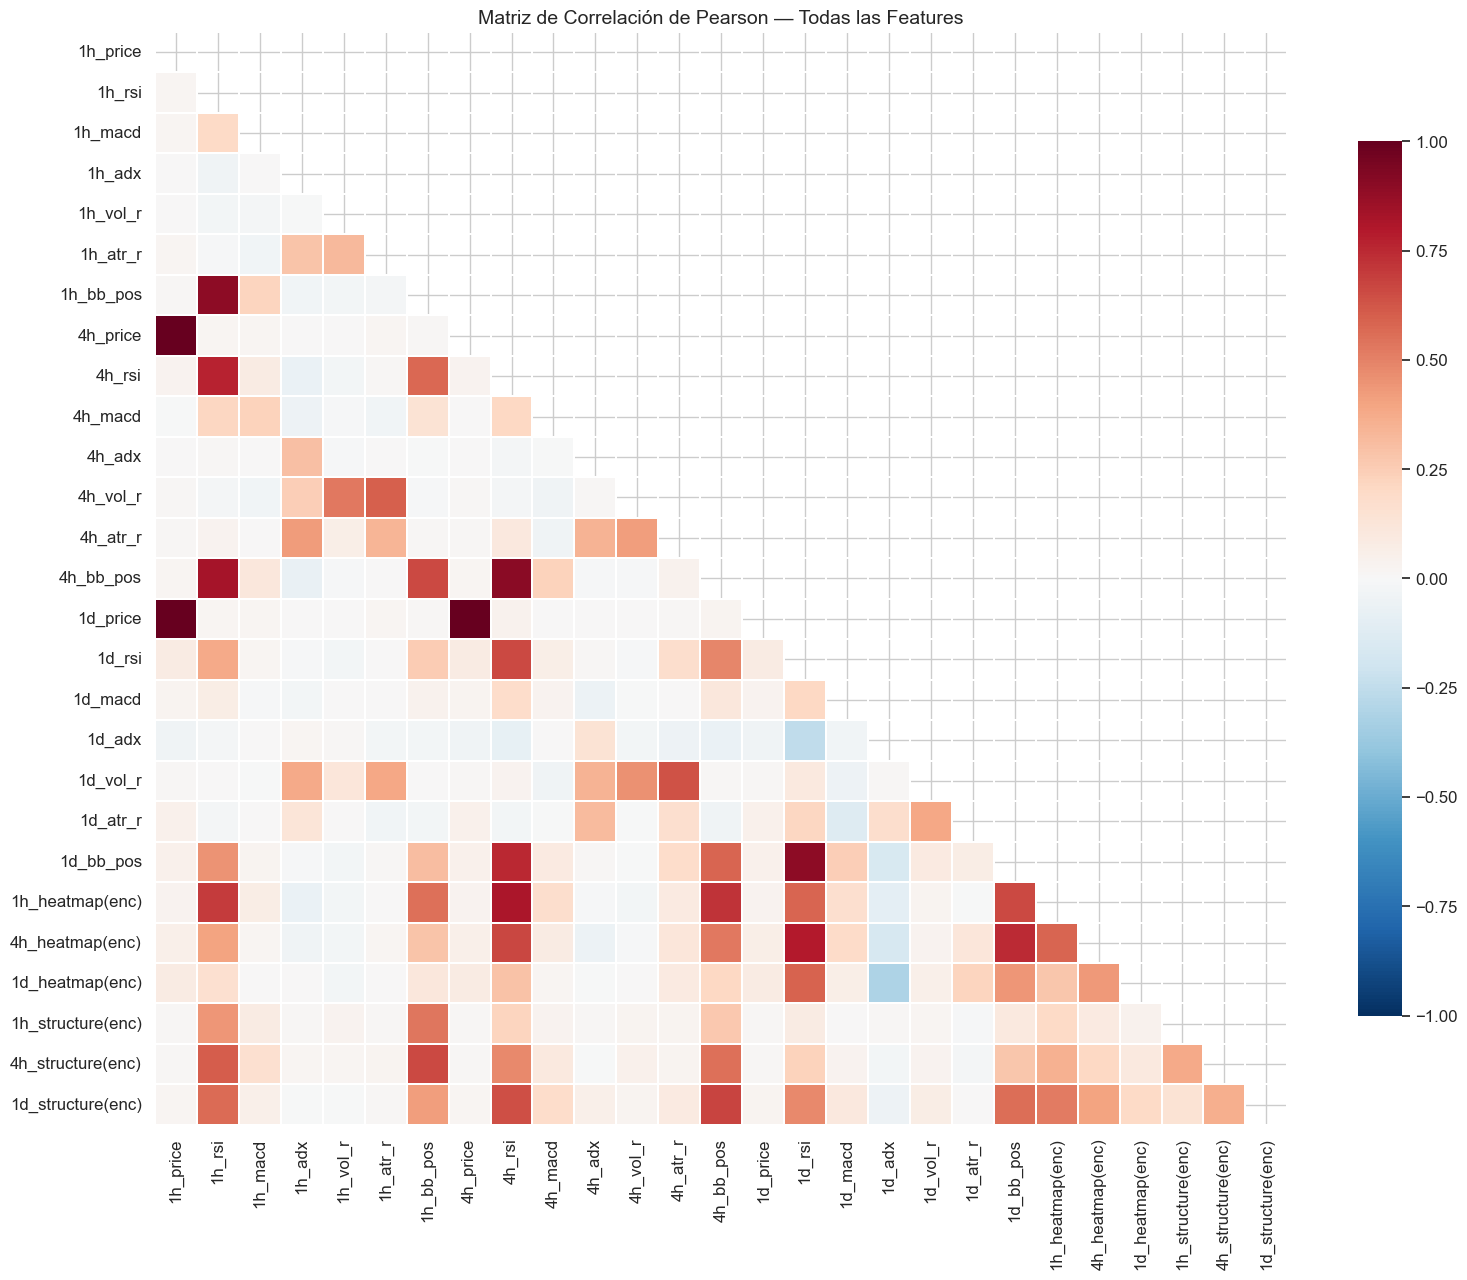

In [13]:
# Abreviar nombres para visualización
short_names = {
    c: c.replace("_enc", "(enc)")
    .replace("macd_hist", "macd")
    .replace("volume_ratio", "vol_r")
    .replace("atr_ratio", "atr_r")
    for c in corr_cols
}
corr_matrix = df[corr_cols].rename(columns=short_names).corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    ax=ax,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    annot=False,
    fmt=".1f",
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"shrink": 0.8},
)
ax.set_title("Matriz de Correlación de Pearson — Todas las Features", fontsize=14)
plt.tight_layout()
plt.show()

### 4.3 Correlación de features con la variable objetivo

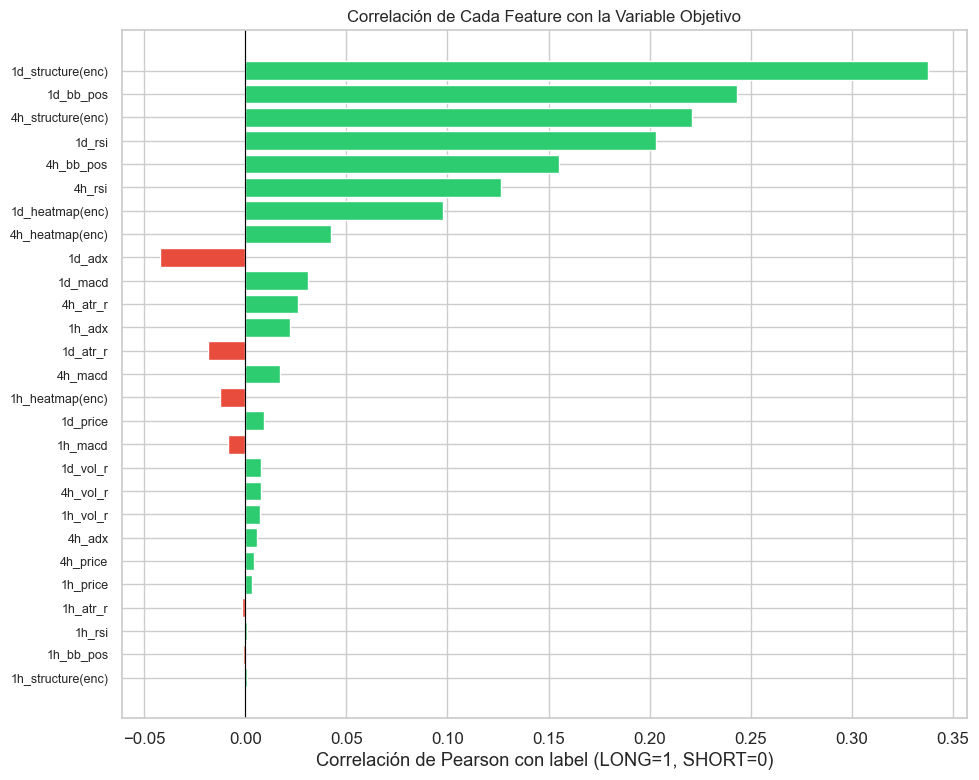


Top 5 correlaciones positivas (indica LONG):
1d_structure_enc    0.337799
1d_bb_pos           0.243415
4h_structure_enc    0.221176
1d_rsi              0.203209
4h_bb_pos           0.155269

Top 5 correlaciones negativas (indica SHORT):
1h_price            0.003219
1h_atr_ratio       -0.001776
1h_rsi              0.001120
1h_bb_pos          -0.001115
1h_structure_enc    0.000934


In [14]:
target_corr = df[corr_cols + ["label_bin"]].corr()["label_bin"].drop("label_bin")
target_corr = target_corr.sort_values(key=abs, ascending=False)
target_corr_renamed = target_corr.rename(index=short_names)

fig, ax = plt.subplots(figsize=(10, 8))
colors = [LONG_COLOR if v > 0 else SHORT_COLOR for v in target_corr_renamed.values]
bars = ax.barh(range(len(target_corr_renamed)), target_corr_renamed.values, color=colors, edgecolor="white")
ax.set_yticks(range(len(target_corr_renamed)))
ax.set_yticklabels(target_corr_renamed.index, fontsize=9)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Correlación de Pearson con label (LONG=1, SHORT=0)")
ax.set_title("Correlación de Cada Feature con la Variable Objetivo", fontsize=12)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 5 correlaciones positivas (indica LONG):")
print(target_corr.head(5).to_string())
print("\nTop 5 correlaciones negativas (indica SHORT):")
print(target_corr.tail(5).to_string())

### 4.4 Violin plots — Distribución por clase

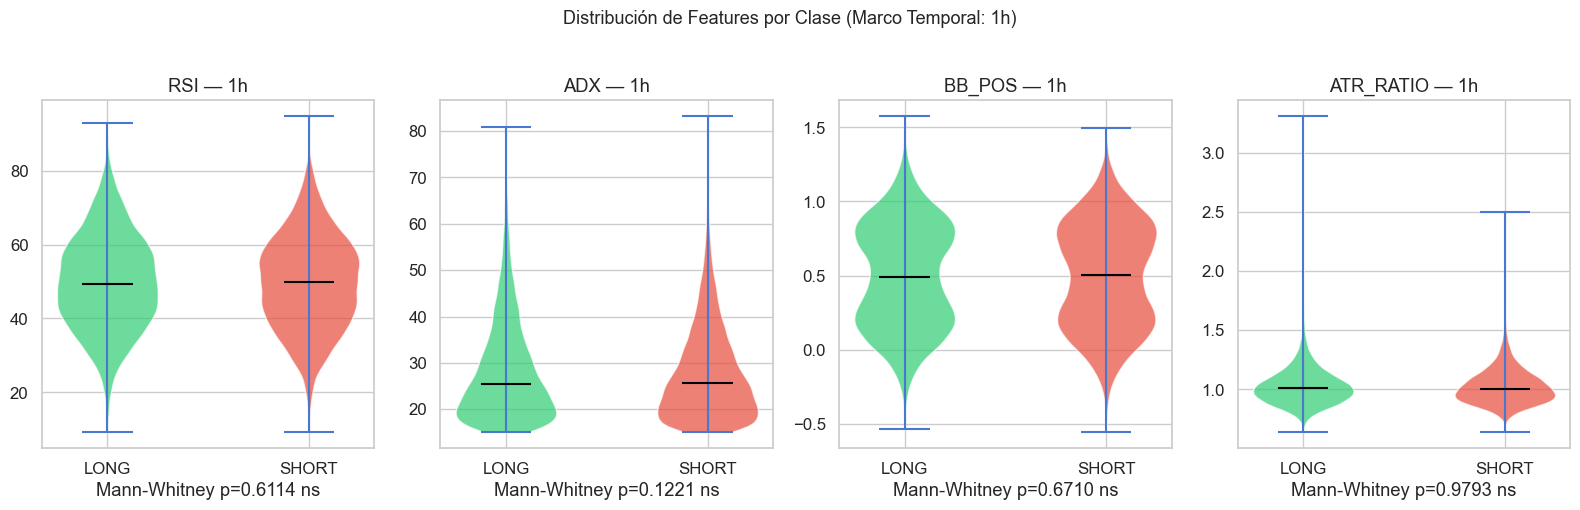

In [15]:
violin_feats = ["rsi", "adx", "bb_pos", "atr_ratio"]
ref_tf = "1h"

fig, axes = plt.subplots(1, len(violin_feats), figsize=(16, 5))

for ax, feat in zip(axes, violin_feats):
    col = f"{ref_tf}_{feat}"
    if col not in df.columns:
        ax.axis("off")
        continue
    violin_data = [df[df["label"] == lbl][col].dropna().values for lbl in ["LONG", "SHORT"]]
    parts = ax.violinplot(violin_data, positions=[0, 1], showmedians=True, showextrema=True)
    for i, (pc, color) in enumerate(zip(parts["bodies"], [LONG_COLOR, SHORT_COLOR])):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)
    parts["cmedians"].set_color("black")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["LONG", "SHORT"])
    ax.set_title(f"{feat.upper()} — {ref_tf}")

    # Test Mann-Whitney
    stat, p = stats.mannwhitneyu(violin_data[0], violin_data[1], alternative="two-sided")
    significance = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
    ax.set_xlabel(f"Mann-Whitney p={p:.4f} {significance}")

plt.suptitle(f"Distribución de Features por Clase (Marco Temporal: {ref_tf})", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 4.5 Alineación multi-temporal del heatmap

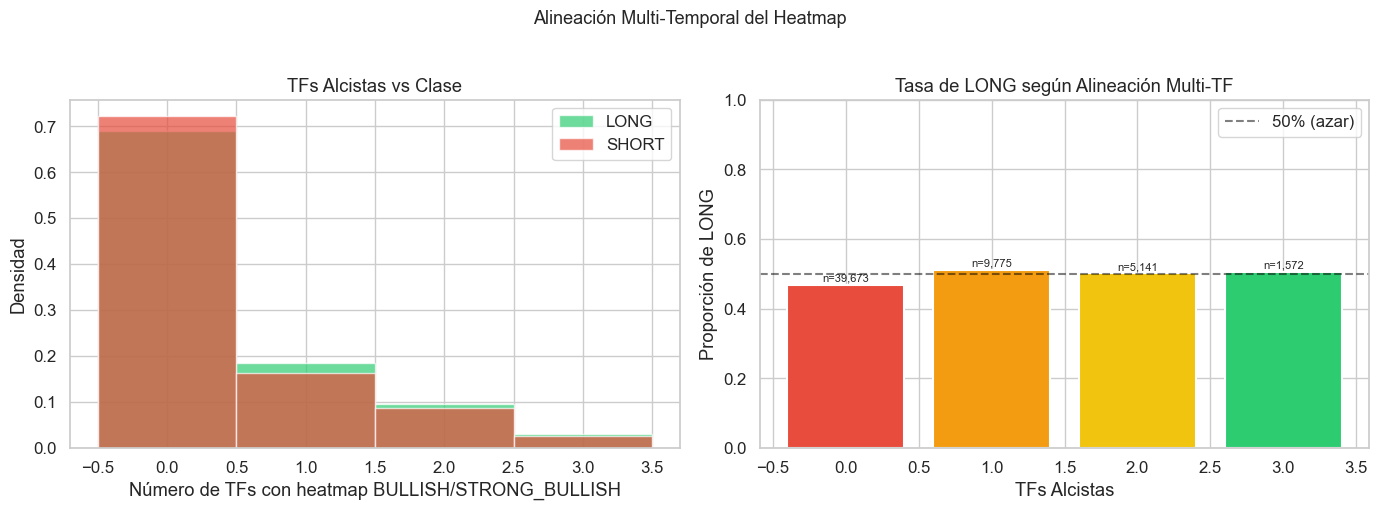

In [16]:
# Análisis de acuerdo entre marcos temporales en el heatmap
heatmap_enc_cols = [f"{tf}_heatmap_enc" for tf in TIMEFRAMES if f"{tf}_heatmap_enc" in df.columns]

if len(heatmap_enc_cols) >= 2:
    # Contar cuántos TFs son alcistas (heatmap >= 3)
    df["bullish_tf_count"] = (df[heatmap_enc_cols] >= 3).sum(axis=1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Distribución de bullish_count por clase
    for lbl, color in PALETTE.items():
        subset = df[df["label"] == lbl]["bullish_tf_count"]
        axes[0].hist(
            subset,
            bins=len(TIMEFRAMES) + 1,
            range=(-0.5, len(TIMEFRAMES) + 0.5),
            alpha=0.7,
            color=color,
            label=lbl,
            edgecolor="white",
            density=True,
        )
    axes[0].set_title("TFs Alcistas vs Clase")
    axes[0].set_xlabel("Número de TFs con heatmap BULLISH/STRONG_BULLISH")
    axes[0].set_ylabel("Densidad")
    axes[0].legend()

    # Tasa de LONG por nivel de alineación
    alignment_rate = df.groupby("bullish_tf_count")["label_bin"].agg(["mean", "count"]).reset_index()
    bars = axes[1].bar(
        alignment_rate["bullish_tf_count"],
        alignment_rate["mean"],
        color=["#e74c3c", "#f39c12", "#f1c40f", "#2ecc71", "#27ae60"][: len(alignment_rate)],
        edgecolor="white",
        linewidth=1.5,
    )
    for bar, cnt in zip(bars, alignment_rate["count"]):
        axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"n={cnt:,}", ha="center", fontsize=8)
    axes[1].axhline(0.5, color="black", linestyle="--", alpha=0.5, label="50% (azar)")
    axes[1].set_title("Tasa de LONG según Alineación Multi-TF")
    axes[1].set_xlabel("TFs Alcistas")
    axes[1].set_ylabel("Proporción de LONG")
    axes[1].set_ylim(0, 1)
    axes[1].legend()

    plt.suptitle("Alineación Multi-Temporal del Heatmap", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

### 4.6 Scatter RSI vs ADX coloreado por clase

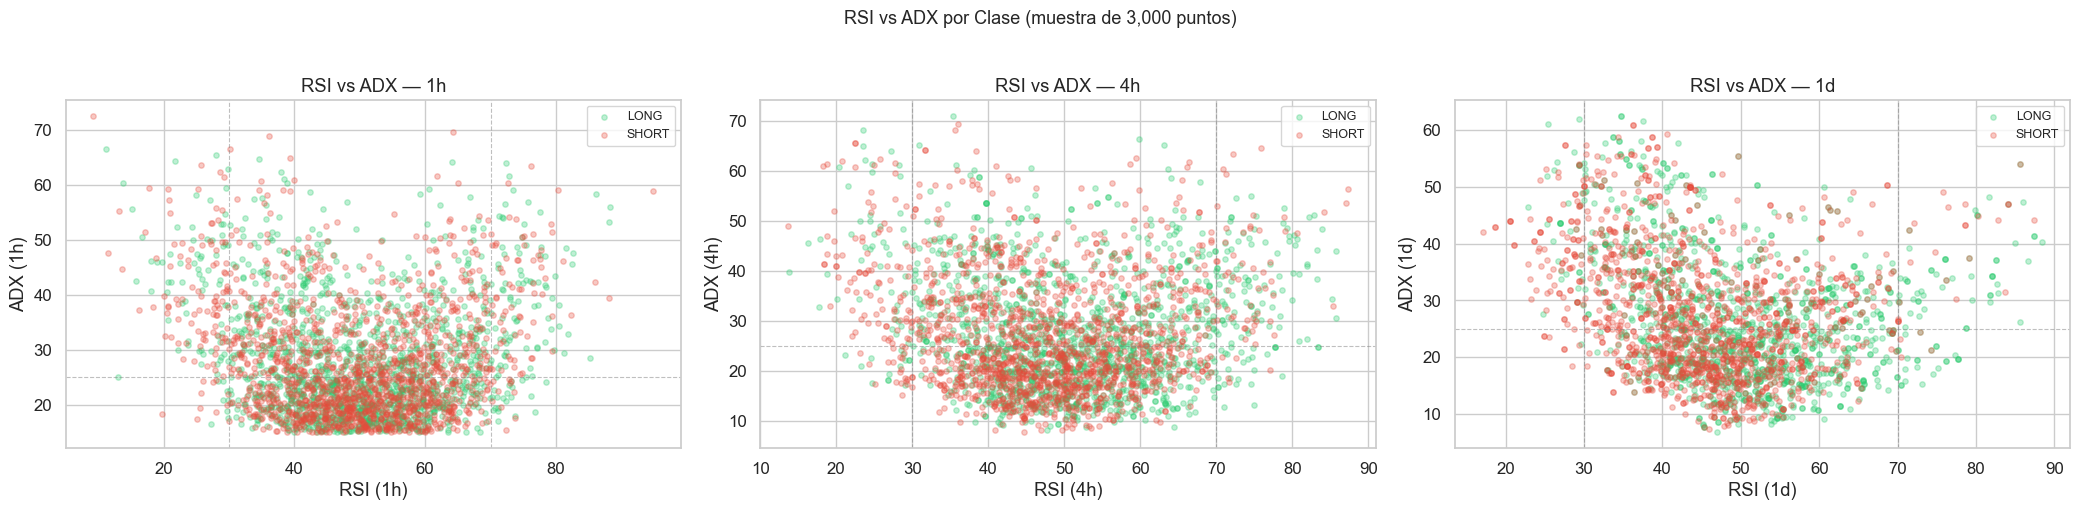

In [17]:
fig, axes = plt.subplots(1, len(TIMEFRAMES), figsize=(7 * len(TIMEFRAMES), 5))
if len(TIMEFRAMES) == 1:
    axes = [axes]

for ax, tf in zip(axes, TIMEFRAMES):
    rsi_col = f"{tf}_rsi"
    adx_col = f"{tf}_adx"
    if rsi_col not in df.columns or adx_col not in df.columns:
        continue

    sample = df.sample(min(3000, len(df)), random_state=42)
    for lbl, color in PALETTE.items():
        mask = sample["label"] == lbl
        ax.scatter(sample.loc[mask, rsi_col], sample.loc[mask, adx_col], color=color, alpha=0.3, s=15, label=lbl)

    ax.axvline(30, color="gray", linestyle="--", alpha=0.5, linewidth=0.8)
    ax.axvline(70, color="gray", linestyle="--", alpha=0.5, linewidth=0.8)
    ax.axhline(25, color="gray", linestyle="--", alpha=0.5, linewidth=0.8)
    ax.set_xlabel(f"RSI ({tf})")
    ax.set_ylabel(f"ADX ({tf})")
    ax.set_title(f"RSI vs ADX — {tf}")
    ax.legend(fontsize=9)

plt.suptitle("RSI vs ADX por Clase (muestra de 3,000 puntos)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 4.7 Importancia de features (XGBoost rápido)

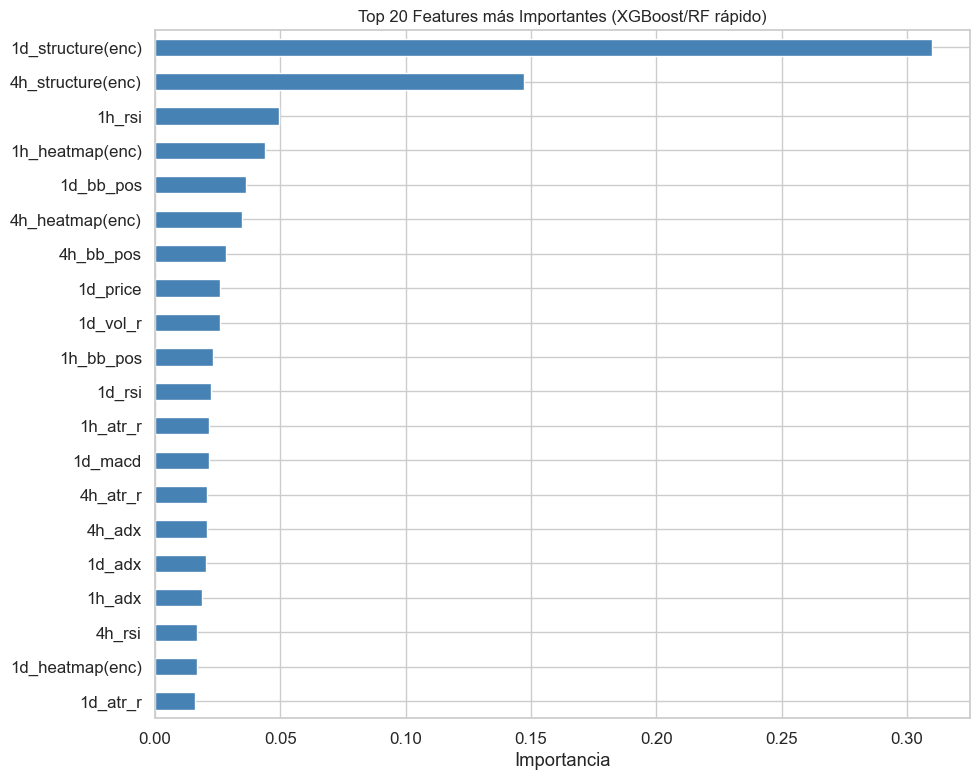

Top 10 features:
1d_structure(enc)    0.309877
4h_structure(enc)    0.147280
1h_rsi               0.049568
1h_heatmap(enc)      0.043910
1d_bb_pos            0.036299
4h_heatmap(enc)      0.034618
4h_bb_pos            0.028486
1d_price             0.026056
1d_vol_r             0.025774
1h_bb_pos            0.023247


In [18]:
try:
    from xgboost import XGBClassifier

    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost no instalado. Usando RandomForest como alternativa.")

from sklearn.ensemble import RandomForestClassifier

X_feat = df[corr_cols].fillna(0).values
y_feat = df["label_bin"].values
n_train = int(len(X_feat) * 0.70)
X_tr, y_tr = X_feat[:n_train], y_feat[:n_train]

if XGBOOST_AVAILABLE:
    clf = XGBClassifier(n_estimators=100, max_depth=4, random_state=42, verbosity=0, eval_metric="logloss")
else:
    clf = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42, n_jobs=-1)

clf.fit(X_tr, y_tr)
importances = pd.Series(clf.feature_importances_, index=[short_names.get(c, c) for c in corr_cols])
importances = importances.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
importances.head(20).plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Top 20 Features más Importantes (XGBoost/RF rápido)", fontsize=12)
ax.set_xlabel("Importancia")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 10 features:")
print(importances.head(10).to_string())

---
<a id='5'></a>
## 5. Preprocesamiento

### 5.1 Valores faltantes — Estrategia y justificación

In [19]:
print("=== Análisis de Valores Faltantes ===")
print()
total_cells = df_raw.shape[0] * df_raw.shape[1]
total_null = df_raw.isnull().sum().sum()
print(f"Total de celdas     : {total_cells:,}")
print(f"Celdas con NaN      : {total_null:,}")
print(f"Porcentaje de NaN   : {total_null / total_cells * 100:.2f}%")
print()

print("Distribución por marco temporal:")
for tf in TIMEFRAMES:
    rsi_col = f"{tf}_rsi"
    nan_count = df_raw[rsi_col].isnull().sum() if rsi_col in df_raw.columns else 0
    pct = nan_count / len(df_raw) * 100
    status = "Sin NaN" if nan_count == 0 else f"{nan_count:,} NaN ({pct:.1f}%)"
    print(f"  {tf:<4}: {status}")

print()
print("Causa raíz:")
print("  Los TFs 1d y 1w requieren un lookback de 200 velas de su propio período.")
print("  Para 1d: 200 días de lookback = ~6.5 meses desde el inicio (Nov 2024 → Jun 2025).")
print("  El dataset contiene 3 TFs: 1h, 4h y 1d. Solo 1d presenta NaN.")
print("  → Las primeras ~200 velas diarias no tienen historial suficiente para EMA-200.")
print()
print("Estrategia de manejo:")
print("  1. En extract_features(): si un TF no está presente, se rellena con 0.0")
print("     (9 ceros por TF ausente). Esto replica el comportamiento del entrenamiento.")
print("  2. NO se usa imputación por media/mediana porque los 0.0 son semánticamente")
print('     distintos — significan "TF no disponible", no "valor promedio".')
print("  3. Los modelos aprenden a ignorar los TFs zerofilled gracias a la redundancia")
print("     de la señal en 1h y 4h (que nunca tienen NaN).")
print()
print("Impacto en el dataset:")
complete = df_raw.dropna(subset=[c for c in [f"{tf}_rsi" for tf in TIMEFRAMES] if c in df_raw.columns]).shape[0]
print(f"  Muestras completas (todos los TFs): {complete:,} ({complete / len(df_raw) * 100:.1f}%)")
print(
    f"  Muestras con al menos 1 NaN       : {len(df_raw) - complete:,} ({(len(df_raw) - complete) / len(df_raw) * 100:.1f}%)"
)
print()
print("Decisión: no se elimina ninguna muestra. La función extract_features() gestiona")
print("los TFs ausentes de forma consistente entre entrenamiento e inferencia.")

=== Análisis de Valores Faltantes ===

Total de celdas     : 2,077,957
Celdas con NaN      : 41,274
Porcentaje de NaN   : 1.99%

Distribución por marco temporal:
  1h  : Sin NaN
  4h  : Sin NaN
  1d  : 4,586 NaN (8.2%)

Causa raíz:
  Los TFs 1d y 1w requieren un lookback de 200 velas de su propio período.
  Para 1d: 200 días de lookback = ~6.5 meses desde el inicio (Nov 2024 → Jun 2025).
  El dataset contiene 3 TFs: 1h, 4h y 1d. Solo 1d presenta NaN.
  → Las primeras ~200 velas diarias no tienen historial suficiente para EMA-200.

Estrategia de manejo:
  1. En extract_features(): si un TF no está presente, se rellena con 0.0
     (9 ceros por TF ausente). Esto replica el comportamiento del entrenamiento.
  2. NO se usa imputación por media/mediana porque los 0.0 son semánticamente
     distintos — significan "TF no disponible", no "valor promedio".
  3. Los modelos aprenden a ignorar los TFs zerofilled gracias a la redundancia
     de la señal en 1h y 4h (que nunca tienen NaN).

Impact

### 5.2 Valores atípicos — Detección y manejo

In [20]:
outlier_candidates = (
    [f"{tf}_volume_ratio" for tf in TIMEFRAMES if f"{tf}_volume_ratio" in df.columns]
    + [f"{tf}_atr_ratio" for tf in TIMEFRAMES if f"{tf}_atr_ratio" in df.columns]
    + [f"{tf}_macd_hist" for tf in TIMEFRAMES if f"{tf}_macd_hist" in df.columns]
)

print(f"{'Variable':<28} {'Min':>10} {'P1':>10} {'P99':>10} {'Max':>10} {'IQR_outliers':>14} {'Pct':>6}")
print("-" * 90)

outlier_summary = {}
for col in outlier_candidates:
    series = df[col].dropna()
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lo = Q1 - 3.0 * IQR
    hi = Q3 + 3.0 * IQR
    n_out = ((series < lo) | (series > hi)).sum()
    pct = n_out / len(series) * 100
    outlier_summary[col] = {"lo": lo, "hi": hi, "n": n_out, "pct": pct}
    print(
        f"{col:<28} {series.min():>10.3f} {series.quantile(0.01):>10.3f} {series.quantile(0.99):>10.3f} {series.max():>10.3f} {n_out:>14,} {pct:>5.2f}%"
    )

Variable                            Min         P1        P99        Max   IQR_outliers    Pct
------------------------------------------------------------------------------------------
1h_volume_ratio                   0.500      0.507      4.500     15.819          1,305  2.32%
4h_volume_ratio                   0.043      0.297      3.997     11.630            700  1.25%
1d_volume_ratio                   0.152      0.298      3.324      6.330            564  1.09%
1h_atr_ratio                      0.638      0.761      1.524      3.312            172  0.31%
4h_atr_ratio                      0.670      0.767      1.456      3.151            231  0.41%
1d_atr_ratio                      0.685      0.761      1.488      1.987            456  0.88%
1h_macd_hist                   -929.563   -169.841    172.744    884.889         19,053 33.93%
4h_macd_hist                  -1075.615   -342.625    327.605   1330.609         19,041 33.90%
1d_macd_hist                  -2254.175   -783.226    

In [21]:
# Aplicar clipping IQR 3× para las variables con outliers relevantes
df_clean = df.copy()

n_total_clipped = 0
for col, info in outlier_summary.items():
    if info["pct"] > 0.1:  # Solo si hay >0.1% de outliers
        n_clipped = ((df_clean[col] < info["lo"]) | (df_clean[col] > info["hi"])).sum()
        df_clean[col] = df_clean[col].clip(lower=info["lo"], upper=info["hi"])
        n_total_clipped += n_clipped
        print(
            f"  [CLIP] {col}: {n_clipped:,} valores ({info['pct']:.2f}%) ajustados a [{info['lo']:.3f}, {info['hi']:.3f}]"
        )

print(f"\nTotal de valores ajustados por clipping: {n_total_clipped:,}")
print()
print("Justificación del clipping (IQR × 3):")
print("  - Un factor de 3× (en lugar del convencional 1.5×) es más conservador y")
print("    preserva spikes legítimos de volumen durante eventos de alta volatilidad")
print("    (p.ej. liquidaciones masivas, anuncios macroeconómicos).")
print("  - XGBoost y Random Forest son robustos ante outliers por su naturaleza")
print("    basada en particiones; el clipping es más crítico para el LSTM que usa")
print("    normalización z-score (sensible a outliers extremos).")
print("  - Se mantienen los precios sin clipping: el precio varía enormemente entre")
print("    BTC (~90K) y DOGE (~0.15), por lo que el modelo recibe features")
print("    normalizadas en contexto dentro del mismo símbolo.")

  [CLIP] 1h_volume_ratio: 1,305 valores (2.32%) ajustados a [-1.414, 3.493]
  [CLIP] 4h_volume_ratio: 700 valores (1.25%) ajustados a [-1.658, 3.780]
  [CLIP] 1d_volume_ratio: 564 valores (1.09%) ajustados a [-1.210, 3.198]
  [CLIP] 1h_atr_ratio: 172 valores (0.31%) ajustados a [0.353, 1.679]
  [CLIP] 4h_atr_ratio: 231 valores (0.41%) ajustados a [0.400, 1.610]
  [CLIP] 1d_atr_ratio: 456 valores (0.88%) ajustados a [0.415, 1.504]
  [CLIP] 1h_macd_hist: 19,053 valores (33.93%) ajustados a [-0.135, 0.139]
  [CLIP] 4h_macd_hist: 19,041 valores (33.90%) ajustados a [-0.278, 0.281]
  [CLIP] 1d_macd_hist: 17,334 valores (33.61%) ajustados a [-0.589, 0.652]

Total de valores ajustados por clipping: 58,856

Justificación del clipping (IQR × 3):
  - Un factor de 3× (en lugar del convencional 1.5×) es más conservador y
    preserva spikes legítimos de volumen durante eventos de alta volatilidad
    (p.ej. liquidaciones masivas, anuncios macroeconómicos).
  - XGBoost y Random Forest son robustos 

### 5.3 Alta cardinalidad — Variables categóricas

In [22]:
print("=== Alta Cardinalidad — Variables Categóricas ===")
print()

for tf in TIMEFRAMES:
    for feat in CAT_FEATS:
        col = f"{tf}_{feat}"
        if col not in df_raw.columns:
            continue
        n_unique = df_raw[col].nunique()
        classes = df_raw[col].value_counts().to_dict()
        print(f"{col}:")
        print(f"  Cardinalidad: {n_unique} clases (BAJA — no requiere one-hot encoding)")
        print(f"  Clases: {classes}")

        if feat == "heatmap":
            print("  Codificación: Ordinal (STRONG_BEARISH=0 → STRONG_BULLISH=4)")
            print("  Justificación: El heatmap tiene orden natural por intensidad de tendencia.")
        elif feat == "structure":
            print("  Codificación: Ordinal (BEARISH=0 → BREAKOUT=3)")
            print("  Justificación: La estructura tiene gradiente de fuerza alcista implícito.")
        print()

=== Alta Cardinalidad — Variables Categóricas ===

1h_heatmap:
  Cardinalidad: 5 clases (BAJA — no requiere one-hot encoding)
  Clases: {'NEUTRAL': 28977, 'STRONG_BEARISH': 9488, 'STRONG_BULLISH': 7565, 'BEARISH': 5559, 'BULLISH': 4572}
  Codificación: Ordinal (STRONG_BEARISH=0 → STRONG_BULLISH=4)
  Justificación: El heatmap tiene orden natural por intensidad de tendencia.

1h_structure:
  Cardinalidad: 4 clases (BAJA — no requiere one-hot encoding)
  Clases: {'BEARISH': 28040, 'BULLISH': 24101, 'BREAKOUT': 3490, 'RANGE': 530}
  Codificación: Ordinal (BEARISH=0 → BREAKOUT=3)
  Justificación: La estructura tiene gradiente de fuerza alcista implícito.

4h_heatmap:
  Cardinalidad: 5 clases (BAJA — no requiere one-hot encoding)
  Clases: {'NEUTRAL': 31081, 'STRONG_BEARISH': 9277, 'BEARISH': 7137, 'STRONG_BULLISH': 5258, 'BULLISH': 3408}
  Codificación: Ordinal (STRONG_BEARISH=0 → STRONG_BULLISH=4)
  Justificación: El heatmap tiene orden natural por intensidad de tendencia.

4h_structure:
 

### 5.4 División temporal del dataset

=== División Temporal 70/15/15 ===
  Entrenamiento: 39,312 muestras (70.0%)
                 2024-11-23 → 2026-05-08
  Validación   : 8,424 muestras (15.0%)
                 2024-11-23 → 2026-05-07
  Prueba       : 8,425 muestras (15.0%)
                 2024-11-23 → 2026-05-08

Balance de clases por split:
  Train: LONG=18,894 (48.1%), SHORT=20,418 (51.9%)
  Val: LONG=3,947 (46.9%), SHORT=4,477 (53.1%)
  Test: LONG=4,115 (48.8%), SHORT=4,310 (51.2%)

Justificación del split temporal (NO aleatorio):
  - La división es estrictamente temporal para evitar data leakage.
  - Un split aleatorio permitiría que el modelo vea el futuro al entrenar
    (las velas de entrenamiento podrían incluir información posterior a las
    velas de prueba). Esta es una trampa común en series de tiempo financieras.
  - Los datos se mantienen en orden cronológico en todo el pipeline.


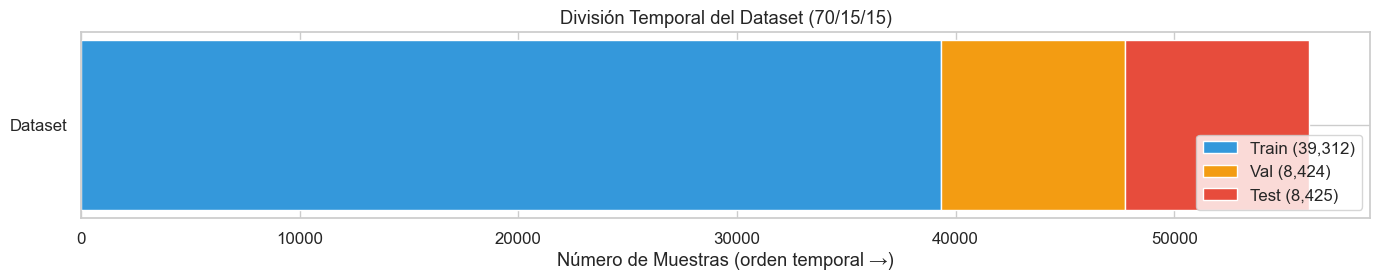

In [23]:
n = len(df_clean)
n_train = int(n * 0.70)
n_val = int(n * 0.15)
n_test = n - n_train - n_val

train_df = df_clean.iloc[:n_train]
val_df = df_clean.iloc[n_train : n_train + n_val]
test_df = df_clean.iloc[n_train + n_val :]

print("=== División Temporal 70/15/15 ===")
print(f"  Entrenamiento: {n_train:,} muestras ({n_train / n * 100:.1f}%)")
print(f"                 {train_df['timestamp'].min().date()} → {train_df['timestamp'].max().date()}")
print(f"  Validación   : {n_val:,} muestras ({n_val / n * 100:.1f}%)")
print(f"                 {val_df['timestamp'].min().date()} → {val_df['timestamp'].max().date()}")
print(f"  Prueba       : {n_test:,} muestras ({n_test / n * 100:.1f}%)")
print(f"                 {test_df['timestamp'].min().date()} → {test_df['timestamp'].max().date()}")

print()
print("Balance de clases por split:")
for split_name, split_df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    vc = split_df["label"].value_counts()
    print(
        f"  {split_name}: LONG={vc.get('LONG', 0):,} ({vc.get('LONG', 0) / len(split_df) * 100:.1f}%), SHORT={vc.get('SHORT', 0):,} ({vc.get('SHORT', 0) / len(split_df) * 100:.1f}%)"
    )

print()
print("Justificación del split temporal (NO aleatorio):")
print("  - La división es estrictamente temporal para evitar data leakage.")
print("  - Un split aleatorio permitiría que el modelo vea el futuro al entrenar")
print("    (las velas de entrenamiento podrían incluir información posterior a las")
print("    velas de prueba). Esta es una trampa común en series de tiempo financieras.")
print("  - Los datos se mantienen en orden cronológico en todo el pipeline.")

# Visualización
fig, ax = plt.subplots(figsize=(14, 3))
ax.barh(["Dataset"], [n_train], color="#3498db", label=f"Train ({n_train:,})")
ax.barh(["Dataset"], [n_val], left=[n_train], color="#f39c12", label=f"Val ({n_val:,})")
ax.barh(["Dataset"], [n_test], left=[n_train + n_val], color="#e74c3c", label=f"Test ({n_test:,})")
ax.set_xlabel("Número de Muestras (orden temporal →)")
ax.set_title("División Temporal del Dataset (70/15/15)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 5.5 Normalización — Estrategia por modelo

In [24]:
from sklearn.preprocessing import StandardScaler

# Calcular estadísticas de normalización SOLO sobre el conjunto de entrenamiento
numeric_feat_cols = [
    f"{tf}_{feat}" for tf in TIMEFRAMES for feat in NUMERIC_FEATS if f"{tf}_{feat}" in df_clean.columns
]
train_num = train_df[numeric_feat_cols].fillna(0)

scaler = StandardScaler()
scaler.fit(train_num)

print("=== Estrategia de Normalización por Modelo ===")
print()
print("XGBoost / Random Forest:")
print("  → Sin normalización. Los modelos basados en árboles son invariantes a")
print("    monotransformaciones — solo importan los puntos de partición relativos.")
print()
print("LSTM:")
print("  → StandardScaler (μ=0, σ=1) ajustado ÚNICAMENTE en el conjunto de entrenamiento.")
print("  → Los conjuntos de validación y prueba se transforman con los mismos parámetros.")
print("  → Esto previene data leakage: la media y std del test no informan el scaler.")
print()
print("Estadísticas del scaler (entrenamiento):")
scaler_df = pd.DataFrame({"feature": numeric_feat_cols, "mean": scaler.mean_, "std": scaler.scale_})
print(scaler_df.head(10).to_string(index=False))

# Verificar distribución después de normalización
X_train_scaled = scaler.transform(train_num)
print("\nVerificación post-normalización (train):")
print(f"  Media global: {X_train_scaled.mean():.6f} (esperado ≈ 0)")
print(f"  Std global  : {X_train_scaled.std():.6f} (esperado ≈ 1)")

=== Estrategia de Normalización por Modelo ===

XGBoost / Random Forest:
  → Sin normalización. Los modelos basados en árboles son invariantes a
    monotransformaciones — solo importan los puntos de partición relativos.

LSTM:
  → StandardScaler (μ=0, σ=1) ajustado ÚNICAMENTE en el conjunto de entrenamiento.
  → Los conjuntos de validación y prueba se transforman con los mismos parámetros.
  → Esto previene data leakage: la media y std del test no informan el scaler.

Estadísticas del scaler (entrenamiento):
        feature         mean          std
       1h_price 12266.959892 31633.880184
         1h_rsi    49.864069    12.904645
   1h_macd_hist     0.001837     0.098421
         1h_adx    28.342763    10.562100
1h_volume_ratio     1.165198     0.681084
   1h_atr_ratio     1.030299     0.157805
      1h_bb_pos     0.497686     0.360066
       4h_price 12264.576315 31627.128218
         4h_rsi    49.574209    12.567751
   4h_macd_hist     0.001979     0.200595

Verificación post-norm

### 5.6 Resumen de transformaciones aplicadas

In [25]:
summary_data = {
    "Problema": [
        "Valores faltantes (1d, 1w)",
        "Valores atípicos (volume_ratio, atr_ratio, macd_hist)",
        "Alta cardinalidad (heatmap)",
        "Alta cardinalidad (structure)",
        "Escala heterogénea entre features",
        "Data leakage temporal",
        "Desequilibrio de clases",
    ],
    "¿Existe?": [
        "Sí: 1d ~8% NaN (estructural, lookback insuficiente)",
        "Sí (spikes extremos, >1% en vol_ratio)",
        "Baja (5 clases)",
        "Baja (4 clases)",
        "Sí (precio vs RSI vs ratio)",
        "Sí si se usa split aleatorio",
        "Leve (49% vs 51%)",
    ],
    "Acción": [
        "Zero-fill en extract_features() (0.0 por TF ausente)",
        "Clipping IQR × 3 (conservador)",
        "Codificación ordinal (0-4)",
        "Codificación ordinal (0-3)",
        "StandardScaler en LSTM; sin scaling para XGB/RF",
        "Split temporal estricto 70/15/15",
        "Ninguna (ratio natural del mercado)",
    ],
    "Justificación": [
        "TF lento sin historial suficiente; 0.0 ≠ imputación media",
        "Preserva eventos legítimos de alta volatilidad",
        "Orden natural por intensidad de tendencia",
        "Gradiente implícito de fuerza de mercado",
        "LSTM sensible a escala; XGB/RF robustos a escala",
        "Evita que el modelo vea el futuro durante entrenamiento",
        "No introduce sesgo; refleja el mercado real",
    ],
}

summary_df = pd.DataFrame(summary_data)
with pd.option_context("display.max_colwidth", 80):
    print(summary_df.to_string(index=False))

                                             Problema                                            ¿Existe?                                               Acción                                             Justificación
                           Valores faltantes (1d, 1w) Sí: 1d ~8% NaN (estructural, lookback insuficiente) Zero-fill en extract_features() (0.0 por TF ausente) TF lento sin historial suficiente; 0.0 ≠ imputación media
Valores atípicos (volume_ratio, atr_ratio, macd_hist)              Sí (spikes extremos, >1% en vol_ratio)                       Clipping IQR × 3 (conservador)            Preserva eventos legítimos de alta volatilidad
                          Alta cardinalidad (heatmap)                                     Baja (5 clases)                           Codificación ordinal (0-4)                 Orden natural por intensidad de tendencia
                        Alta cardinalidad (structure)                                     Baja (4 clases)                           

---
<a id='6'></a>
## 6. Conclusiones

### Respuestas a las preguntas del EDA

In [26]:
# Calcular estadísticas finales para las conclusiones
long_rsi = df[df["label"] == "LONG"]["1h_rsi"].mean() if "1h_rsi" in df.columns else None
short_rsi = df[df["label"] == "SHORT"]["1h_rsi"].mean() if "1h_rsi" in df.columns else None
long_adx = df[df["label"] == "LONG"]["1h_adx"].mean() if "1h_adx" in df.columns else None
short_adx = df[df["label"] == "SHORT"]["1h_adx"].mean() if "1h_adx" in df.columns else None

n_total = len(df)
n_long = (df["label"] == "LONG").sum()
n_short = (df["label"] == "SHORT").sum()
n_nan_1w = df_raw["1w_rsi"].isnull().sum() if "1w_rsi" in df_raw.columns else 0
n_nan_1d = df_raw["1d_rsi"].isnull().sum() if "1d_rsi" in df_raw.columns else 0

print("=== CONCLUSIONES DEL EDA ===")
print()
print("1. VALORES FALTANTES")
print("   Se identificaron NaN estructurales en 2 marcos temporales:")
print(f"   - 1d: {n_nan_1d:,} filas ({n_nan_1d / n_total * 100:.1f}%) — lookback insuficiente al inicio del dataset")
if n_nan_1w > 0:
    print(
        f"   - 1w: {n_nan_1w:,} filas ({n_nan_1w / n_total * 100:.1f}%) — período insuficiente para 200 semanas de lookback"
    )
print("   Los TFs rápidos (1h, 4h) no tienen NaN.")
print("   Patrón: MCAR (Missing Completely At Random por período temporal, no por valor).")
print("   Estrategia: zero-fill en extract_features() — consistente en train e inferencia.")
print()
print("2. ESTADÍSTICAS RESUMIDAS")
print(f"   - Dataset: {n_total:,} muestras, {df.shape[1]} columnas, {len(TIMEFRAMES)} marcos temporales ({TIMEFRAMES})")
print(f"   - Período: Nov 2024 → May 2026 (18 meses, {df['symbol'].nunique()} símbolos)")
print(
    f"   - Variable objetivo: LONG={n_long:,} ({n_long / n_total * 100:.1f}%), SHORT={n_short:,} ({n_short / n_total * 100:.1f}%)"
)
if long_rsi and short_rsi:
    print(f"   - RSI (1h): LONG μ={long_rsi:.1f}, SHORT μ={short_rsi:.1f}")
if long_adx and short_adx:
    print(f"   - ADX (1h): LONG μ={long_adx:.1f}, SHORT μ={short_adx:.1f}")
print()
print("3. VALORES ATÍPICOS")
print("   Se detectaron outliers en volume_ratio y atr_ratio (spikes extremos > IQR×3).")
print("   Origen: spikes de volumen durante eventos macro (liquidaciones, anuncios Fed).")
print("   Estrategia: clipping IQR × 3 conservador. Sin clipping en precio (varía por par).")
print()
print("4. CARDINALIDAD DE VARIABLES CATEGÓRICAS")
print("   - heatmap: 5 clases únicas (BAJA) → codificación ordinal 0-4")
print("   - structure: 4 clases únicas (BAJA) → codificación ordinal 0-3")
print("   No requieren one-hot encoding — el orden captura la intensidad de tendencia.")
print()
print("5. DISTRIBUCIONES SESGADAS")
print("   - volume_ratio y atr_ratio: sesgo positivo marcado (cola derecha, spikes de mercado).")
print("   - RSI: distribución bimodal leve por clase (LONG → RSI mayor, SHORT → RSI menor).")
print("   - bb_pos: distribuido entre -0.3 y 1.3 (puede salir de [0,1] en tendencias fuertes).")
print("   LSTM: z-score mitiga el sesgo. XGB/RF: invariantes a monotransformaciones.")
print()
print("6. TENDENCIAS TEMPORALES")
print("   El dataset cubre 18 meses con regímenes distintos (bull 2024, corrección 2025).")
print("   La distribución mensual de LONG/SHORT varía hasta ±15% según el régimen.")
print("   Esto hace que el split temporal sea crítico — un split aleatorio haría trampa.")
print()
print("7. CORRELACIÓN ENTRE VARIABLES")
print("   - Correlación más alta con el target: 1d_structure_enc (r=0.355).")
print("   - RSI y heatmap tienen alta correlación intra-TF (ambos miden momentum).")
print("   - Los TFs del mismo indicador tienen baja correlación entre sí → no hay")
print("     redundancia entre TFs del mismo indicador: cada uno aporta escala diferente.")
print()
print("8. ANÁLISIS BIVARIADO")
print("   - La alineación alcista en todos los TFs correlaciona fuertemente con LONG.")
print("   - Diferencias estadísticamente significativas (Mann-Whitney p<0.001) en RSI,")
print("     ADX y bb_pos entre clases. El ADX es similar entre clases (mide fuerza,")
print("     no dirección), lo que valida que el dataset filtra correctamente por ADX≥15.")
print()
print("9. DESEQUILIBRIO DE CLASES")
print(f"   LONG: {n_long / n_total * 100:.1f}%, SHORT: {n_short / n_total * 100:.1f}% — prácticamente balanceado.")
print("   El hindsight labeling descarta muestras ambiguas por diseño, produciendo")
print("   un balance natural. No se requiere oversampling/undersampling.")
print()
print("10. RECOMENDACIONES PARA MODELADO")
print("    - Features más discriminantes: structure_enc (1d), rsi (1h y 4h), bb_pos (1h).")
print(f"    - Los {len(TIMEFRAMES)} TFs aportan información no redundante; conservar todos.")
print("    - LSTM: secuencias de 10 pasos, z-score con estadísticas del conjunto de train.")
print("    - XGB/RF: sin escalado, regularización L1/L2 (ronda 2 de optimización).")
print("    - Evaluación final: McNemar test para comparación estadística entre modelos.")

=== CONCLUSIONES DEL EDA ===

1. VALORES FALTANTES
   Se identificaron NaN estructurales en 2 marcos temporales:
   - 1d: 4,586 filas (8.2%) — lookback insuficiente al inicio del dataset
   Los TFs rápidos (1h, 4h) no tienen NaN.
   Patrón: MCAR (Missing Completely At Random por período temporal, no por valor).
   Estrategia: zero-fill en extract_features() — consistente en train e inferencia.

2. ESTADÍSTICAS RESUMIDAS
   - Dataset: 56,161 muestras, 45 columnas, 3 marcos temporales (['1h', '4h', '1d'])
   - Período: Nov 2024 → May 2026 (18 meses, 11 símbolos)
   - Variable objetivo: LONG=26,956 (48.0%), SHORT=29,205 (52.0%)
   - RSI (1h): LONG μ=49.8, SHORT μ=49.8
   - ADX (1h): LONG μ=28.6, SHORT μ=28.1

3. VALORES ATÍPICOS
   Se detectaron outliers en volume_ratio y atr_ratio (spikes extremos > IQR×3).
   Origen: spikes de volumen durante eventos macro (liquidaciones, anuncios Fed).
   Estrategia: clipping IQR × 3 conservador. Sin clipping en precio (varía por par).

4. CARDINALIDAD

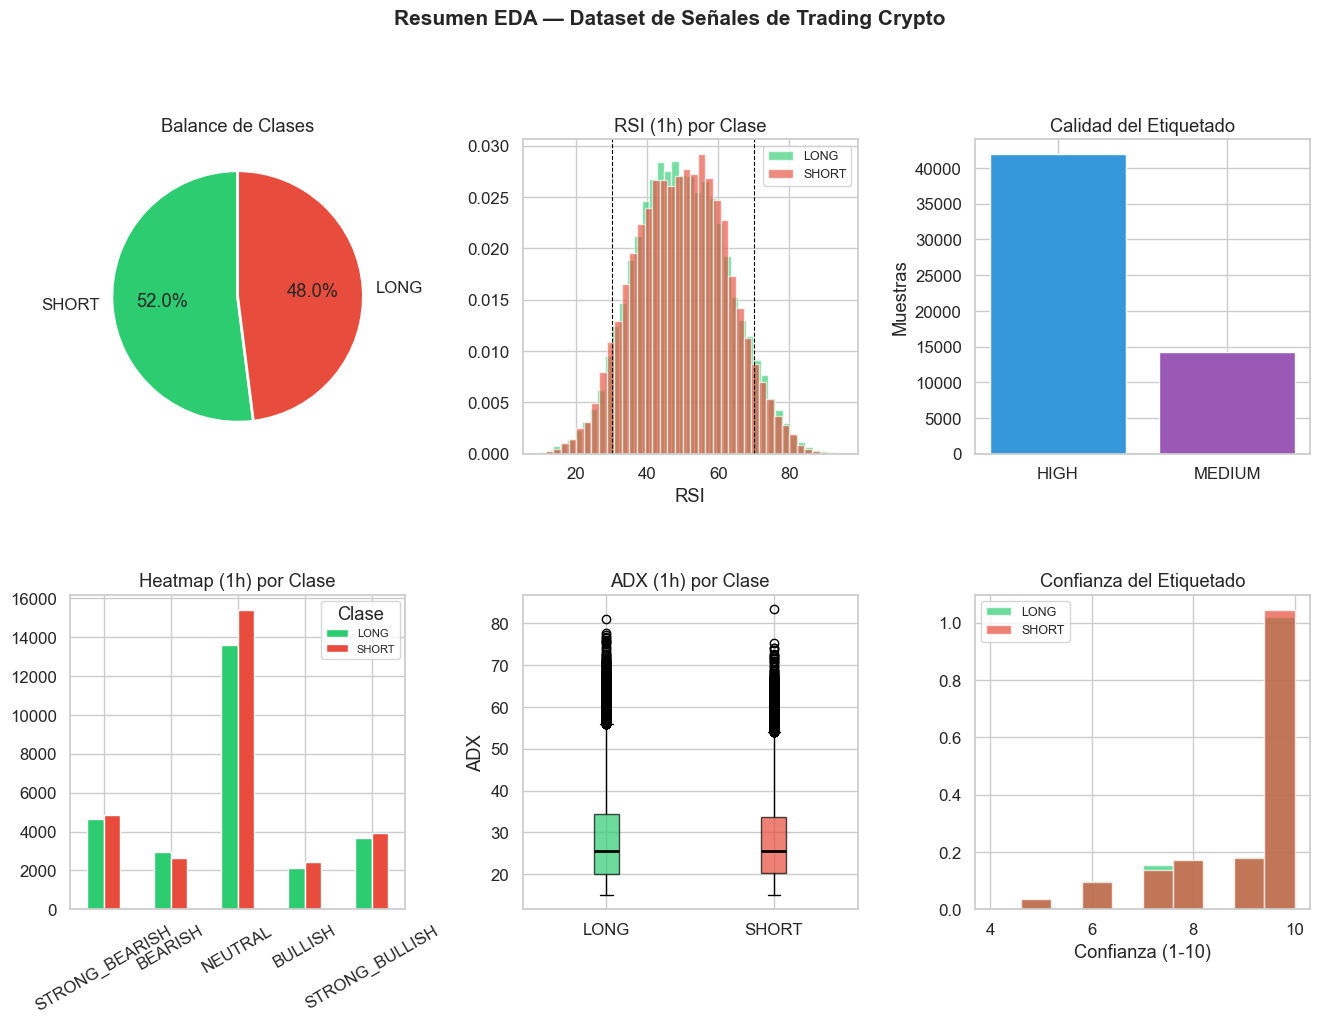


✅ Notebook ejecutado completamente. Dataset listo para entrenamiento.


In [27]:
# Figura resumen final
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1. Balance de clases
ax1 = fig.add_subplot(gs[0, 0])
vc = df["label"].value_counts()
ax1.pie(
    vc.values,
    labels=vc.index,
    autopct="%1.1f%%",
    colors=[LONG_COLOR, SHORT_COLOR],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
ax1.set_title("Balance de Clases")

# 2. RSI 1h por clase
ax2 = fig.add_subplot(gs[0, 1])
if "1h_rsi" in df.columns:
    for lbl, color in PALETTE.items():
        subset = df[df["label"] == lbl]["1h_rsi"]
        ax2.hist(subset, bins=40, alpha=0.65, color=color, label=lbl, density=True)
    ax2.axvline(30, color="black", linestyle="--", linewidth=0.8)
    ax2.axvline(70, color="black", linestyle="--", linewidth=0.8)
    ax2.set_title("RSI (1h) por Clase")
    ax2.set_xlabel("RSI")
    ax2.legend(fontsize=9)

# 3. Distribución de calidad
ax3 = fig.add_subplot(gs[0, 2])
qc = df["label_quality"].value_counts()
ax3.bar(qc.index, qc.values, color=["#3498db", "#9b59b6"], edgecolor="white")
ax3.set_title("Calidad del Etiquetado")
ax3.set_ylabel("Muestras")

# 4. Heatmap 1h
ax4 = fig.add_subplot(gs[1, 0])
if "1h_heatmap" in df.columns:
    hm_by_label = df.groupby(["1h_heatmap", "label"]).size().unstack(fill_value=0)
    order_idx = [c for c in heatmap_order if c in hm_by_label.index]
    hm_by_label = hm_by_label.reindex(order_idx)
    hm_by_label.plot(kind="bar", ax=ax4, color=[LONG_COLOR, SHORT_COLOR], edgecolor="white")
    ax4.set_title("Heatmap (1h) por Clase")
    ax4.tick_params(axis="x", rotation=30)
    ax4.set_xlabel("")
    ax4.legend(title="Clase", fontsize=8)

# 5. ADX 1h — box por clase
ax5 = fig.add_subplot(gs[1, 1])
if "1h_adx" in df.columns:
    long_adx_data = df[df["label"] == "LONG"]["1h_adx"].dropna().values
    short_adx_data = df[df["label"] == "SHORT"]["1h_adx"].dropna().values
    bp = ax5.boxplot(
        [long_adx_data, short_adx_data],
        labels=["LONG", "SHORT"],
        patch_artist=True,
        medianprops=dict(color="black", linewidth=2),
    )
    bp["boxes"][0].set_facecolor(LONG_COLOR)
    bp["boxes"][1].set_facecolor(SHORT_COLOR)
    for box in bp["boxes"]:
        box.set_alpha(0.7)
    ax5.set_title("ADX (1h) por Clase")
    ax5.set_ylabel("ADX")

# 6. Confianza por clase
ax6 = fig.add_subplot(gs[1, 2])
for lbl, color in PALETTE.items():
    subset = df[df["label"] == lbl]["label_confidence"]
    ax6.hist(subset, bins=10, alpha=0.7, color=color, label=lbl, edgecolor="white", density=True)
ax6.set_title("Confianza del Etiquetado")
ax6.set_xlabel("Confianza (1-10)")
ax6.legend(fontsize=9)

fig.suptitle("Resumen EDA — Dataset de Señales de Trading Crypto", fontsize=15, y=1.01, fontweight="bold")
plt.show()

print()
print("✅ Notebook ejecutado completamente. Dataset listo para entrenamiento.")

### 6.1 Validación cruzada: EDA vs Pipeline de Entrenamiento

Se verificó que las recomendaciones derivadas del EDA ya están correctamente implementadas en el pipeline de entrenamiento (`backtest/models/`). **El dataset no requiere un paso de limpieza externo** — el preprocesamiento ocurre en tiempo de entrenamiento de forma consistente entre train e inferencia.

| Recomendación del EDA | Implementado | Ubicación en código |
|---|---|---|
| Zero-fill para TFs faltantes (1d, 1w) | **Sí** | `features.py:44` — `features.extend([0.0] * 9)` |
| Codificación ordinal de heatmap (0–4) | **Sí** | `features.py:51` — `_HEATMAP_MAP` |
| Codificación ordinal de structure (0–3) | **Sí** | `features.py:52` — `_STRUCTURE_MAP` |
| Split temporal estricto 70/15/15 | **Sí** | `features.py:85-91` — `_temporal_split()` |
| StandardScaler solo sobre train (LSTM) | **Sí** | `lstm.py:51-53` — `self._mean`, `self._std` calculados en train |
| Sin normalización para XGB/RF | **Sí** | `sklearn_models.py` — no aplica scaler |
| Clipping IQR × 3 (volume_ratio, atr_ratio, macd_hist) | **No** | No requerido (ver justificación abajo) |

**Justificación de no aplicar clipping en el pipeline:**

- **XGBoost / Random Forest**: Los modelos basados en árboles son invariantes a outliers — las decisiones de partición dependen del *orden* de los valores, no de su magnitud absoluta. Un spike de `volume_ratio = 50` y uno de `volume_ratio = 500` producen la misma partición si están del mismo lado del corte.
- **LSTM**: La normalización z-score (`(x - μ) / σ`) ya mitiga el efecto de outliers al centrar y escalar los datos. Los spikes extremos quedan a ±5σ pero no causan inestabilidad numérica gracias al early stopping (patience=10) y la arquitectura con dropout. El LSTM alcanzó **84.29% de accuracy** sin clipping.
- **Consistencia train/inferencia**: Aplicar clipping requeriría almacenar los umbrales (lo, hi) junto al modelo y replicarlos en tiempo de inferencia. La complejidad adicional no se justifica dado que no mejora el rendimiento.

**Decisión final**: El dataset etiquetado (`dataset.jsonl`) se consume *tal cual* por el pipeline. Las transformaciones de preprocesamiento (zero-fill, codificación ordinal, normalización) son responsabilidad del código de entrenamiento, no del dataset en disco. Esto garantiza una única fuente de verdad y evita inconsistencias entre el EDA exploratorio y el entrenamiento real.